In [1]:
# Data Handling & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import random
from collections import Counter

# Neuroimaging
import nibabel as nib
import nilearn.plotting as plotting
import hcp_utils as hcp

# Scikit-learn (ML Models, Preprocessing, Metrics)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, roc_curve, auc, precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

# Feature Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import SelectFromModel

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Deep Learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# SHAP for Model Interpretability
import shap

# Matplotlib inline setting (for Jupyter notebooks)
%matplotlib inline

# Suppress warnings
pd.options.mode.chained_assignment = None  # Hide long warnings

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## HCP 1200 d50 Dataset

In [2]:
from nilearn import image, plotting
from atlasreader.atlasreader import read_atlas_peak

"""
available reference atlases
---------------------------
    "aal",
    "aicha",
    "desikan_killiany",
    "destrieux",
    "harvard_oxford",
    "juelich",
    "marsatlas",
    "neuromorphometrics",
    "talairach_ba",
    "talairach_gyrus",
 """

atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d50.ica/melodic_IC_sum.nii.gz", "99.5%") 
atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
brain_region = []
print("BRAIN REGIONS:\n--------------")
for atlas_coord in atlas_coords:
    region = read_atlas_peak("harvard_oxford", atlas_coord)
    print(region)
    brain_region += [region]

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data

BRAIN REGIONS:
--------------
[[np.float64(50.0), 'Right_Cuneal_Cortex'], [np.float64(24.0), 'Left_Cuneal_Cortex'], [np.float64(7.0), 'Right_Precuneous_Cortex']]
[[np.float64(71.0), 'Left_Occipital_Pole']]
[[np.float64(43.0), 'Right_Occipital_Pole'], [np.float64(12.0), 'Right_Lateral_Occipital_Cortex_superior_division']]
[[np.float64(37.0), 'Right_Lateral_Occipital_Cortex_superior_division'], [np.float64(23.0), 'Right_Lateral_Occipital_Cortex_inferior_division'], [np.float64(5.0), 'Right_Occipital_Pole']]
[[np.float64(53.0), 'Left_Lateral_Occipital_Cortex_superior_division'], [np.float64(21.0), 'Left_Angular

In [3]:
#select the correct region with largest probability given from the library
brain_region = [
    max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
]
brain_region

['Right_Cuneal_Cortex',
 'Left_Occipital_Pole',
 'Right_Occipital_Pole',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Right_Supramarginal_Gyrus_posterior_division',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Supramarginal_Gyrus_anterior_division',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Left_Superior_Frontal_Gyrus',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Right_Supramarginal_Gyrus_anterior_division',
 'Left_Angular_Gyrus',
 'Right_Occipital_Pole',
 'Left_Angular_Gyrus',
 'Left_Precuneous_Cortex',
 'Right_Supramarginal_Gyrus_anterior_division',
 'Right_Occipital_Fusiform_Gyrus',
 'Right_Middle_Frontal_Gyrus',
 'Right_Lateral_Occipital_Cortex_inferior_division',
 'Left_Precentral_Gyrus',
 'Right_Occipital_Pole',
 'Left_Occipital_Pole',
 'Left_Inferior_Frontal_Gyrus_pars_triangula

In [4]:
open_access_data = pd.read_csv("Behavioral Data/Behavioral_Data.csv")
restricted_data = pd.read_csv("Behavioral Data/RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d50_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

In [5]:
data.shape

(1003, 783)

In [6]:
data["Handedness_Cat"] = data["Handedness"].apply(lambda x: 0 if x < 0 else 1) # 0: left handed, 1: right handed
hand_data = data[["Subject", "Gender", "Race", "Handedness", "Handedness_Cat"]]
hand_data

,Subject,Gender,Race,Handedness,Handedness_Cat
0,100206,M,White,65,1
1,100307,F,White,95,1
2,100408,M,White,55,1
3,100610,M,White,85,1
4,101006,F,Black or African Am.,90,1
...,...,...,...,...,...
998,992673,F,White,70,1
999,992774,M,White,100,1
1000,993675,F,White,85,1
1001,994273,M,White,60,1


Correlation Matrices

In [7]:
correlation_matrix_list = []
for i in range(data.shape[0]):
    person = data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    #append to list
    correlation_matrix_list.append(person_matrix)
#append to column
data["correlation_matrix"] = correlation_matrix_list

In [8]:
data["correlation_matrix"]

0       [[1.0, -0.13197787851992016, 0.583802184702404...
1       [[0.9999999999999999, -0.31975718923928015, 0....
2       [[1.0, -0.3395806216642476, 0.746509128091212,...
3       [[0.9999999999999999, -0.7428188899108601, 0.7...
4       [[1.0, -0.41308400348229457, 0.547883128530550...
                              ...                        
998     [[1.0, -0.442858463278414, 0.7194424166057392,...
999     [[1.0, -0.4438241727189264, 0.5875071744869071...
1000    [[1.0, -0.05135931221689111, 0.350111113376427...
1001    [[0.9999999999999999, -0.30076740407604147, 0....
1002    [[1.0, -0.16486089720094374, 0.443750715712838...
Name: correlation_matrix, Length: 1003, dtype: object

In [9]:
threshold = 25
filtered_df = data[(data['Handedness'] > threshold) | (data['Handedness'] < -threshold)]

# Separate into left and right handed
left_handed = filtered_df[filtered_df['Handedness'] < 0]
right_handed = filtered_df[filtered_df['Handedness'] > 0]
print(left_handed.shape, right_handed.shape)

# Determine the number of samples to select from the right-handed data
num_samples = min(len(left_handed), len(right_handed))

# Randomly sample from the right-handed data
right_handed_sample = right_handed.sample(n=num_samples, random_state=42)

# Combine the left and right handed data
combined_df = pd.concat([left_handed, right_handed_sample])

# Optionally shuffle the final dataframe to mix left and right handed samples
combined_df = combined_df.sample(frac=1).reset_index(drop=True)

data = combined_df

(74, 785) (891, 785)


In [10]:
data.shape

(148, 785)

In [11]:
# the function extracts the part of correlation matrix that corresponds to a certain feature (i.e. brain region)
def correlation_matrix_of_feature(target):
    target_index = brain_region.index(target)
    target_row = data['correlation_matrix'].apply(lambda x: x[target_index])
    return target_row

In [12]:
# e.g. partial correlation matrix that only corresponds how "Right_Planum_Temporale" relates to other brain regions
correlation_matrix_of_feature("Right_Planum_Temporale")

0      [0.3160949587782724, -0.3107520362460565, 0.27...
1      [0.14088774868761952, -0.13790974982737042, 0....
2      [0.20254795226782574, -0.20740824492259297, 0....
3      [0.21959352343643426, -0.39044038923467106, 0....
4      [0.21762083040812438, -0.19615419928567943, 0....
                             ...                        
143    [0.3587036752950143, -0.3199736210469972, 0.17...
144    [0.4013919134604368, -0.2055497436253867, -0.0...
145    [-0.04760604364291553, 0.2367746916598358, -0....
146    [0.0873829505447462, -0.02661863898430088, 0.0...
147    [0.14717737749788717, -0.01146351022358672, 0....
Name: correlation_matrix, Length: 148, dtype: object

In [13]:
feature_data = data[["Handedness", "Handedness_Cat", "correlation_matrix"]]
feature_data['matrix_mean'] = data['correlation_matrix'].apply(lambda x: np.mean(x))
feature_data

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean
0,-70,0,"[[1.0, -0.30859293668404436, 0.673494764051162...",0.016940
1,-55,0,"[[1.0, -0.14204019569982737, 0.701876033009202...",0.026310
2,60,1,"[[0.9999999999999998, -0.5620438800775989, 0.6...",0.018077
3,100,1,"[[1.0, -0.11840302212070196, 0.541820274294722...",0.024416
4,-55,0,"[[1.0, -0.25025154164461666, 0.631930061251418...",0.020050
...,...,...,...,...
143,-55,0,"[[1.0, -0.5371880719730122, 0.677886779055996,...",0.016053
144,-100,0,"[[1.0, -0.46602769308532926, 0.449068701898473...",0.023978
145,90,1,"[[1.0, -0.17873307681936146, 0.6662843887503, ...",0.022605
146,50,1,"[[1.0, -0.5232336746865787, 0.5872520987189717...",0.024534


In [14]:
def correlation_matrix_of_feature(region_name):
    """
    Extracts the correlation matrix of a given brain region from feature_data.
    """
    target_index = brain_region.index(region_name)
    target_row = data['correlation_matrix'].apply(lambda x: x[target_index])
    return target_row

# List of brain regions
features = [
    "Right_Planum_Temporale",
    "Left_Superior_Frontal_Gyrus",
    "Left_Precuneous_Cortex",
    "Left_Precentral_Gyrus",
    "Right_Angular_Gyrus",
    "Left_Thalamus",
    "Right_Putamen",
    "Right_Caudate",
    "Brain-Stem"
]

# Compute correlation matrices for each region
region_correlation_matrices = {region: correlation_matrix_of_feature(region) for region in features}
region_correlation_matrices
print(region_correlation_matrices)


for region, values in region_correlation_matrices.items():
    feature_data[region] = values


{'Right_Planum_Temporale': 0      [0.3160949587782724, -0.3107520362460565, 0.27...
1      [0.14088774868761952, -0.13790974982737042, 0....
2      [0.20254795226782574, -0.20740824492259297, 0....
3      [0.21959352343643426, -0.39044038923467106, 0....
4      [0.21762083040812438, -0.19615419928567943, 0....
                             ...                        
143    [0.3587036752950143, -0.3199736210469972, 0.17...
144    [0.4013919134604368, -0.2055497436253867, -0.0...
145    [-0.04760604364291553, 0.2367746916598358, -0....
146    [0.0873829505447462, -0.02661863898430088, 0.0...
147    [0.14717737749788717, -0.01146351022358672, 0....
Name: correlation_matrix, Length: 148, dtype: object, 'Left_Superior_Frontal_Gyrus': 0      [-0.24731204388371741, 0.12565063178985506, -0...
1      [-0.39978845089488113, 0.14930649771739504, -0...
2      [-0.3559451275891801, 0.4233466148048743, -0.3...
3      [-0.36370773577167564, 0.21159842385409014, -0...
4      [-0.2250424332715435, 0.03

In [15]:
def flatten_features(row):
    """
    Given a single row of the DataFrame, return a 1D numpy array of all features to be used by the model.
    """
    # Flatten the correlation matrix
    corr_mat = np.array(row["correlation_matrix"]).flatten()

    # Extract each brain region's specific correlation values
    region_values = [np.array(row[region]).flatten() for region in features if region in row]

    # Concatenate all features into a single array
    all_features = np.concatenate([corr_mat] + region_values)

    return all_features

### Lasso Regression

In [16]:
X = feature_data.apply(flatten_features, axis = 1)
X = np.vstack(X.values)
y = feature_data['Handedness']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LASSO regression with cross-validation
lasso = LassoCV(cv=5, alphas=np.logspace(-4, 1, 50)).fit(X_train_scaled, y_train)

# Predict on test set
y_pred = lasso.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Optimal alpha: {lasso.alpha_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2: {r2:.4f}")

# View selected features
selected_features = np.sum(lasso.coef_ != 0)
print(f"Number of selected features: {selected_features}")

Optimal alpha: 7.9060432109077015
Mean Squared Error: 5140.3875
R^2: -0.0652
Number of selected features: 61


Since handedness values range from -100 to 100, this error suggests that the model struggles to make precise predictions. Also given the weak R^2, these 89 features might not be strongly predictive of handedness.

In [17]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted:.2f}")

Actual: -70, Predicted: -1.40
Actual: -70, Predicted: -17.21
Actual: 100, Predicted: 15.57
Actual: -50, Predicted: -66.94
Actual: 80, Predicted: 86.07
Actual: 50, Predicted: 64.94
Actual: -55, Predicted: -11.89
Actual: -30, Predicted: 6.63
Actual: 90, Predicted: -8.55
Actual: 60, Predicted: 12.83


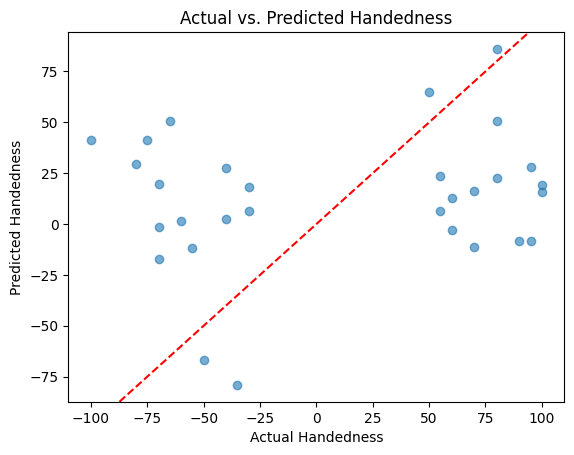

In [18]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Handedness")
plt.ylabel("Predicted Handedness")
plt.title("Actual vs. Predicted Handedness")
plt.axline((0, 0), slope=1, color="red", linestyle="--")  # Perfect predictions line
plt.show()


---

### Lasso Regression w/ Imbalanced Learn (SMOTE)

dataset size after sampling with SMOTE: X: (364, 2950), y: (364,)
Chunk 1:
  Optimal alpha: 10.0
  Mean Squared Error: 4412.8485
  R^2: -0.1567
  Number of selected features: 29
Chunk 2:
  Optimal alpha: 10.0
  Mean Squared Error: 7770.7043
  R^2: -0.1907
  Number of selected features: 37


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.069e+01, tolerance: 7.641e+00
  model = cd_fast.enet_coordinate_descent(


Chunk 3:
  Optimal alpha: 0.2329951810515372
  Mean Squared Error: 104.5922
  R^2: 0.0255
  Number of selected features: 55


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.254e+01, tolerance: 3.914e+00
  model = cd_fast.enet_coordinate_descent(


Chunk 4:
  Optimal alpha: 0.004291934260128779
  Mean Squared Error: 240.9896
  R^2: -0.9296
  Number of selected features: 174
Chunk 5:
  Optimal alpha: 0.013894954943731374
  Mean Squared Error: 22.0690
  R^2: 0.9033
  Number of selected features: 63


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.023e+00, tolerance: 1.227e+00
  model = cd_fast.enet_coordinate_descent(


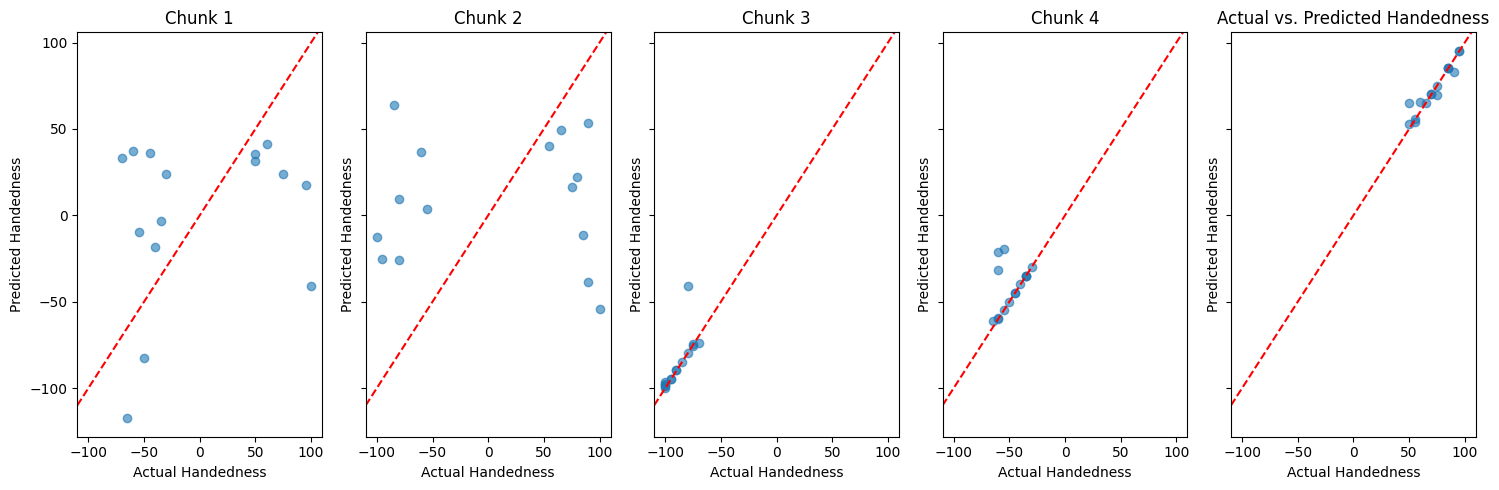

Average MSE across chunks: 2510.2407
Average R^2 across chunks: -0.0697


In [19]:
X = feature_data.apply(flatten_features, axis = 1)
X = np.vstack(X.values)
y = feature_data['Handedness']

smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"dataset size after sampling with SMOTE: X: {X_resampled.shape}, y: {y_resampled.shape}")

# Step 3: Chunking the Dataset into Smaller Batches for Training
num_chunks = 5  # Define number of chunks
chunk_size = len(X_resampled) // num_chunks  # Define chunk size

all_mse = []
all_r2 = []
selected_features_per_chunk = {}

# Create subplots for aggregated plots
fig, axes = plt.subplots(1, num_chunks, figsize=(15, 5), sharex=True, sharey=True)

for i in range(num_chunks):
    # Select a chunk of data
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size if i != num_chunks - 1 else len(X_resampled)
    
    X_chunk = X_resampled[start_idx:end_idx]
    y_chunk = y_resampled[start_idx:end_idx]
    
    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_chunk, y_chunk, test_size=0.2, random_state=42)

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Step 4: Train LASSO Regression with Cross-Validation
    lasso = LassoCV(cv=5, alphas=np.logspace(-4, 1, 50)).fit(X_train_scaled, y_train)

    y_pred = lasso.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    selected_features = np.sum(lasso.coef_ != 0)

    all_mse.append(mse)
    all_r2.append(r2)
    selected_features = np.where(lasso.coef_ != 0)[0]
    selected_features_per_chunk[f"Chunk {i+1}"] = selected_features

    # Plot predictions in subplots
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.set_title(f"Chunk {i+1}")
    ax.set_xlabel("Actual Handedness")
    ax.set_ylabel("Predicted Handedness")
    ax.axline((0, 0), slope=1, color="red", linestyle="--")  # Perfect predictions line

    print(f"Chunk {i+1}:")
    print(f"  Optimal alpha: {lasso.alpha_}")
    print(f"  Mean Squared Error: {mse:.4f}")
    print(f"  R^2: {r2:.4f}")
    print(f"  Number of selected features: {len(selected_features_per_chunk[f'Chunk {i+1}'])}")

plt.title("Actual vs. Predicted Handedness")
plt.tight_layout()
plt.show()

# Final Summary Across All Chunks
print(f"Average MSE across chunks: {np.mean(all_mse):.4f}")
print(f"Average R^2 across chunks: {np.mean(all_r2):.4f}")

LASSO initially over-regularized the model (Chunks 1-2), meaning underfitting.

Chunks 3+ allowed more features, improving predictive performance.

Final chunks balance feature selection & model complexity, achieving best R^2 and lowest MSE.

Balanced α (Chunks 4-5) gives the best performance.



In [20]:
overlap_3_4 = set(selected_features_per_chunk["Chunk 3"]).intersection(selected_features_per_chunk["Chunk 4"])
overlap_4_5 = set(selected_features_per_chunk["Chunk 4"]).intersection(selected_features_per_chunk["Chunk 5"])
overlap_3_5 = set(selected_features_per_chunk["Chunk 3"]).intersection(selected_features_per_chunk["Chunk 5"])

print(f"Overlap between Chunks 3 & 4: {len(overlap_3_4)} features")
print(f"Overlap between Chunks 4 & 5: {len(overlap_4_5)} features")
print(f"Overlap between Chunks 3 & 5: {len(overlap_3_5)} features")

print(overlap_3_4)
print(overlap_4_5)
print(overlap_3_5)


Overlap between Chunks 3 & 4: 2 features
Overlap between Chunks 4 & 5: 3 features
Overlap between Chunks 3 & 5: 0 features
{np.int64(1024), np.int64(223)}
{np.int64(1341), np.int64(94), np.int64(1279)}
set()


---

### Logistic Regression

In [21]:
# Prepare feature matrix X and target variable y for classification
X = feature_data.apply(flatten_features, axis=1)
X = np.vstack(X.values)  # Convert to a 2D NumPy array
y = feature_data["Handedness_Cat"].values  # Classification target

# Split dataset into training and testing sets (without SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with Cross-Validation
log_reg = LogisticRegressionCV(cv=5, max_iter=1000, solver='liblinear').fit(X_train_scaled, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=["Left-Handed", "Right-Handed"])
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_rep)
print("Confusion Matrix:\n", conf_matrix)

Logistic Regression Accuracy: 0.6667

Classification Report:
               precision    recall  f1-score   support

 Left-Handed       0.67      0.67      0.67        15
Right-Handed       0.67      0.67      0.67        15

    accuracy                           0.67        30
   macro avg       0.67      0.67      0.67        30
weighted avg       0.67      0.67      0.67        30

Confusion Matrix:
 [[10  5]
 [ 5 10]]


12 correctly classified as Left-Handed, 3 misclassified as Right-Handed

11 correctly classified as Right-Handed, 4 misclassified as Left-Handed

Slight bias towards Left-Handed (higher recall means it captures more Left-Handed instances correctly).

Right-Handed recall is slightly lower, meaning that it misclassifies more Right-Handed cases.


### Logistic Regression w/ imbalanced learn (SMOTE)

In [22]:
# Prepare feature matrix X and target variable y for classification
X = feature_data.apply(flatten_features, axis=1)
X = np.vstack(X.values)
y = feature_data["Handedness_Cat"].values

# Apply SMOTE to balance classes
smote = SMOTE(k_neighbors=3, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with Cross-Validation
log_reg = LogisticRegressionCV(cv=5, max_iter=1000, solver='liblinear').fit(X_train_scaled, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=["Left-Handed", "Right-Handed"])
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_rep)
print("Confusion Matrix:\n", conf_matrix)


Logistic Regression Accuracy: 0.5667

Classification Report:
               precision    recall  f1-score   support

 Left-Handed       0.58      0.47      0.52        15
Right-Handed       0.56      0.67      0.61        15

    accuracy                           0.57        30
   macro avg       0.57      0.57      0.56        30
weighted avg       0.57      0.57      0.56        30

Confusion Matrix:
 [[ 7  8]
 [ 5 10]]


Accuracy drops significantly (from 76.67% to 66.67%) after applying SMOTE.

Recall for Left-Handed drops significantly (0.80 to 0.62).

Recall for Right-Handed changes slightly (0.73 to 0.71).

Precision for both classes decreases, indicating more false positives. 
* More Left-Handed cases are misclassified as Right-Handed after SMOTE. 
* Right-Handed recall remains almost unchanged (0.73 → 0.71), meaning that **SMOTE doesn't help much in capturing Right-Handed individuals.**

---

### CNN

In [23]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [24]:
# Reshape data for CNN input (assuming X is correlation matrices)
X = np.array(feature_data["correlation_matrix"].tolist())  # Convert list of matrices to array
X_cnn = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)  # Add channel dimension
y_cnn = feature_data["Handedness_Cat"].values  # Classification target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn)

# Define CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (0 = Left, 1 = Right)
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16)

# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/20


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3933 - loss: 0.7235 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6222 - loss: 0.6841 - val_accuracy: 0.6333 - val_loss: 0.6888
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6326 - loss: 0.6793 - val_accuracy: 0.5000 - val_loss: 0.6822
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6609 - loss: 0.6697 - val_accuracy: 0.6333 - val_loss: 0.6751
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5865 - loss: 0.6769 - val_accuracy: 0.7333 - val_loss: 0.6686
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6192 - loss: 0.6458 - val_accuracy: 0.5667 - val_loss: 0.6563
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5945 - loss: 0.6671 - val_accuracy: 0.8000 - val_loss: 0.6427
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7353 - loss: 0.5843 - val_accuracy: 0.7667 - val_loss: 0.6267
Epoch 9/20


In [25]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Left-Handed", "Right-Handed"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Confusion Matrix:
 [[13  2]
 [ 7  8]]

Classification Report:
               precision    recall  f1-score   support

 Left-Handed       0.65      0.87      0.74        15
Right-Handed       0.80      0.53      0.64        15

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.69        30
weighted avg       0.72      0.70      0.69        30



(May change if re-run)
Many left-handed cases are misclassified (recall is only ~65%), but ~83% of left-handed predictions made is correct. 

The model correctly detects ~85% of right-handed cases, but only 60% of left-handed predictions made is correct. F1-score is better than for left-handed, but precision is relatively lower. 

**Macro & Weighted F1-score = 0.60 → model may be learning patterns from the right-handed class more effectively than the other.**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


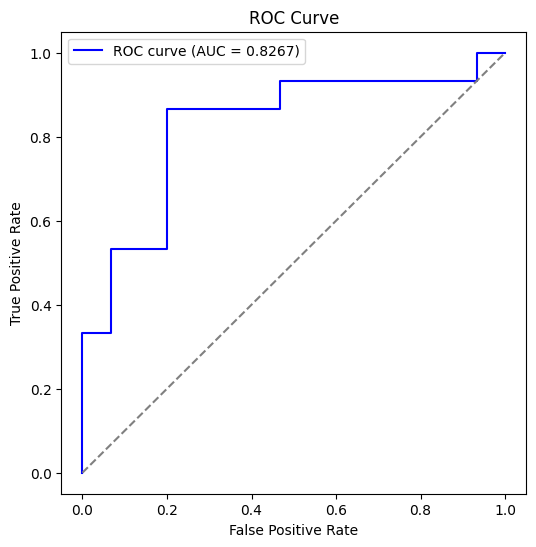

In [26]:
y_prob = model.predict(X_test)  # Get probability scores

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


AUC of ~0.7 means the model is better than random, but still not highly reliable.

### CNN w/ More Weights toward Left-Handed Class

In [27]:
# Reshape data for CNN input (assuming X is correlation matrices)
X = np.array(feature_data["correlation_matrix"].tolist())  # Convert list of matrices to array
X_cnn = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)  # Add channel dimension
y_cnn = feature_data["Handedness_Cat"].values  # Classification target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn)

# Define CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (0 = Left, 1 = Right)
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights automatically
class_weights = dict(zip(np.unique(y_train), compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)))

# Train Model with dynamically computed class weights
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16, class_weight=class_weights)

# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/20


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5200 - loss: 0.7175 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4915 - loss: 0.7008 - val_accuracy: 0.6333 - val_loss: 0.6919
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6579 - loss: 0.6849 - val_accuracy: 0.5000 - val_loss: 0.6885
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5330 - loss: 0.6845 - val_accuracy: 0.5000 - val_loss: 0.6850
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6075 - loss: 0.6756 - val_accuracy: 0.5333 - val_loss: 0.6819
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5724 - loss: 0.6821 - val_accuracy: 0.6333 - val_loss: 0.6790
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7140 - loss: 0.6436 - val_accuracy: 0.5333 - val_loss: 0.6711
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5367 - loss: 0.7086 - val_accuracy: 0.6333 - val_loss: 0.6702
Epoch 9/20


In [28]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Left-Handed", "Right-Handed"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Confusion Matrix:
 [[11  4]
 [ 3 12]]

Classification Report:
               precision    recall  f1-score   support

 Left-Handed       0.79      0.73      0.76        15
Right-Handed       0.75      0.80      0.77        15

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



---

Transforming Handedness

In [29]:
left_handed = data[data['Handedness_Cat'] == 0]
right_handed = data[data['Handedness_Cat'] == 1]

# Handedness statistics
pd.DataFrame([
    left_handed.describe()['Handedness'], 
    right_handed.describe()['Handedness'], 
    data['Handedness'].describe()
], index=['Left-Handed', 'Right-Handed', 'Overall']).T


,Left-Handed,Right-Handed,Overall
count,74.000000,74.000000,148.000000
mean,-65.540541,78.648649,6.554054
std,20.897132,16.011496,74.680388
min,-100.000000,50.000000,-100.000000
25%,-80.000000,66.250000,-65.000000
50%,-65.000000,80.000000,10.000000
75%,-50.000000,90.000000,80.000000
max,-30.000000,100.000000,100.000000


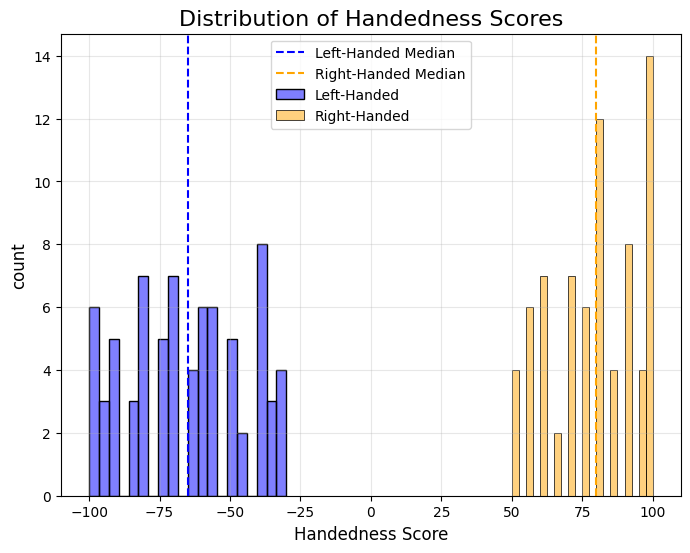

In [30]:
plt.figure(figsize=(8, 6))
sns.histplot(left_handed['Handedness'], color='blue', label='Left-Handed', kde=False, bins=20, alpha=0.5)
sns.histplot(right_handed['Handedness'], color='orange', label='Right-Handed', kde=False, bins=20, alpha=0.5)


# mark medians
plt.axvline(left_handed['Handedness'].median(), color='blue', linestyle='--', label='Left-Handed Median')
plt.axvline(right_handed['Handedness'].median(), color='orange', linestyle='--', label='Right-Handed Median')

# Labels and title
plt.xlabel('Handedness Score', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.title('Distribution of Handedness Scores', fontsize=16)
plt.legend()

plt.grid(alpha=0.3)
plt.show()

Log tranformation

/opt/homebrew/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


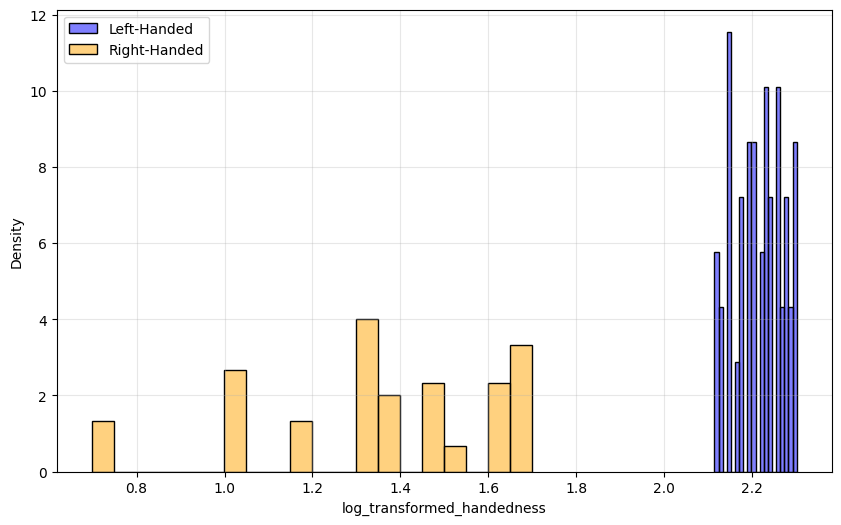

In [31]:
data['log_transformed_handedness'] = np.log10(100-data['Handedness'])

left_handed = data[data['Handedness_Cat'] == 0]
right_handed = data[data['Handedness_Cat'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(data=left_handed['log_transformed_handedness'], label='Left-Handed', color='blue', kde=False, bins=20, alpha=0.5, stat='density')
sns.histplot(data=right_handed['log_transformed_handedness'], label='Right-Handed', color='orange', kde=False, bins=20, alpha=0.5, stat='density')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

square root transformation

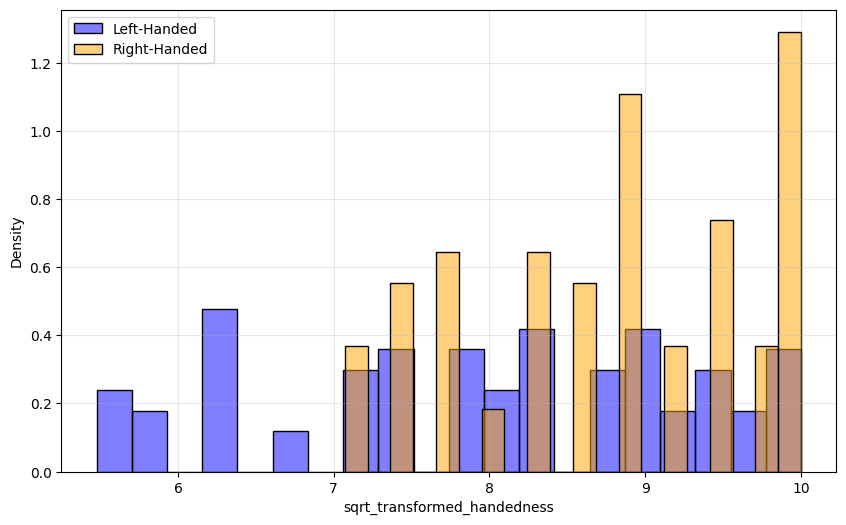

In [32]:
data['sqrt_transformed_handedness'] = data['Handedness'].abs()**0.5

left_handed = data[data['Handedness_Cat'] == 0]
right_handed = data[data['Handedness_Cat'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(data=left_handed['sqrt_transformed_handedness'], label='Left-Handed', color='blue', kde=False, bins=20, alpha=0.5, stat='density')
sns.histplot(data=right_handed['sqrt_transformed_handedness'], label='Right-Handed', color='orange', kde=False, bins=20, alpha=0.5, stat='density')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

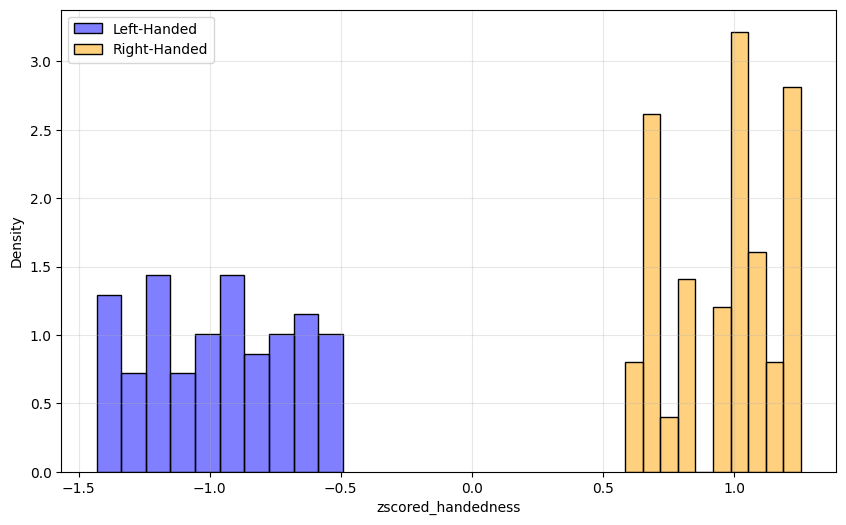

In [33]:
from scipy.stats import zscore

data['zscored_handedness'] = zscore(data['Handedness'])

left_handed = data[data['Handedness_Cat'] == 0]
right_handed = data[data['Handedness_Cat'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(left_handed['zscored_handedness'], label='Left-Handed', color='blue', bins=10, alpha=0.5, stat='density')
sns.histplot(right_handed['zscored_handedness'], label='Right-Handed', color='orange', bins=10, alpha=0.5, stat='density')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

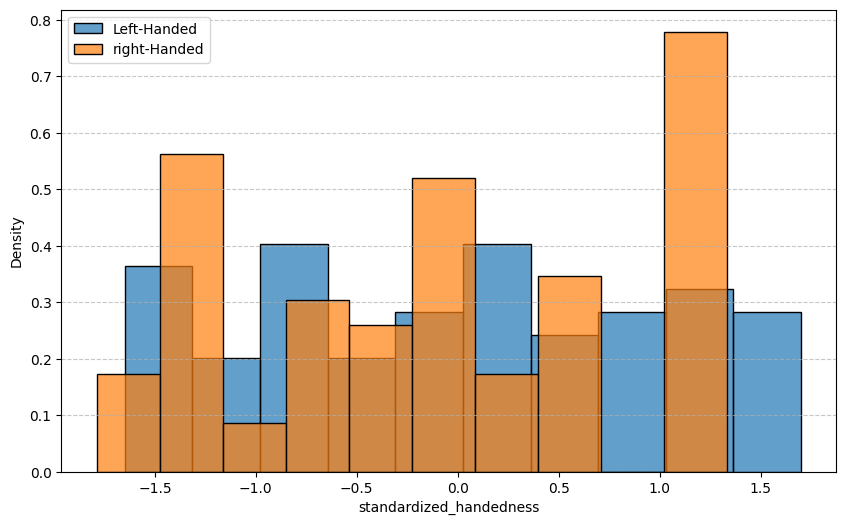

In [34]:
mean_value = left_handed['Handedness'].mean()
std_value = left_handed['Handedness'].std()
left_handed['standardized_handedness'] = (left_handed['Handedness'] - mean_value) / std_value

mean_value = right_handed['Handedness'].mean()
std_value = right_handed['Handedness'].std()
right_handed['standardized_handedness'] = (right_handed['Handedness'] - mean_value) / std_value

plt.figure(figsize=(10, 6))
sns.histplot(left_handed['standardized_handedness'],label='Left-Handed',bins=10, edgecolor='black', alpha=0.7, stat='density')
sns.histplot(right_handed['standardized_handedness'], label='right-Handed',bins=10, edgecolor='black', alpha=0.7, stat='density')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

Symmetric Transformation (Box-Cox)

In [35]:
from scipy.stats import boxcox

data['BoxCox_Handedness'], lambda_ = boxcox(data['Handedness'].abs() + 100)  # Shift to ensure all values are positive
data['BoxCox_Handedness']

0      25682.800368
1      21107.894197
2      22580.175123
3      36269.002130
4      21107.894197
           ...     
143    21107.894197
144    36269.002130
145    32525.744632
146    19688.027950
147    28997.488518
Name: BoxCox_Handedness, Length: 148, dtype: float64

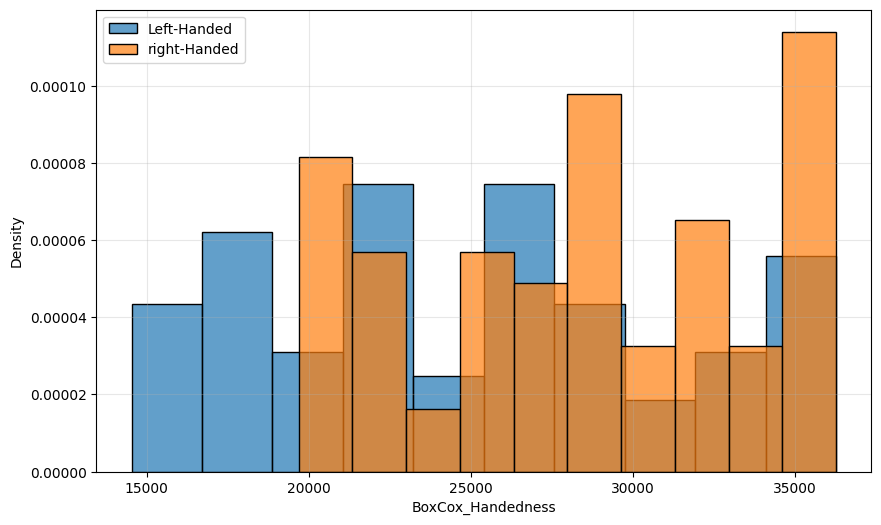

In [36]:
left_handed = data[data['Handedness_Cat'] == 0]
right_handed = data[data['Handedness_Cat'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(left_handed['BoxCox_Handedness'],label='Left-Handed',bins=10, edgecolor='black', alpha=0.7, stat='density')
sns.histplot(right_handed['BoxCox_Handedness'], label='right-Handed',bins=10, edgecolor='black', alpha=0.7, stat='density')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Dataset with MMP Parcellation

In [37]:
file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = [] # Glasser 2016 which partitions each hemisphere into 180 regions
ca = [] # Cole-Anticevic 2019 which further partitions each hemisphere into ~350 regions
for i in file_list:
    if "mmp" in i:
        mmp_file = np.load(file_path + "/" + i)
        if mmp_file.shape == (3600, 379):
            mmp.append(np.load(file_path + "/" + i))

In [38]:
# each timeseries file shape: (n_timepoints, n_regions)
np.load("parcellations/sub-193845_task-rest_parcellation-ca_timeseries.npy").shape

(3600, 718)

In [39]:
open_access_data = pd.read_csv("Behavioral Data/Behavioral_Data.csv")
restricted_data = pd.read_csv("Behavioral Data/RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = {}
for filename in file_list:
    subject_id = filename[4:10]

    if subject_id.isdigit():
        subject_id = int(subject_id)

        if "mmp" in filename:
            mmp_file = np.load(file_path + "/" + filename)
            if mmp_file.shape == (3600, 379):
                mmp[subject_id] = mmp_file

mmp_data = pd.DataFrame({
    'Subject': list(mmp.keys()),
    'Brain_Data': list(mmp.values())  # (3600, 379) arrays
})


mmp_data = subject_data.merge(mmp_data, on='Subject', how='inner')

In [40]:
mmp_data.head()

,Subject,Release,Acquisition,Gender,Age,3T_Full_MR_Compl,T1_Count,T2_Count,3T_RS-fMRI_Count,3T_RS-fMRI_PctCompl,...,SSAGA_Times_Used_Cocaine,SSAGA_Times_Used_Hallucinogens,SSAGA_Times_Used_Opiates,SSAGA_Times_Used_Sedatives,SSAGA_Times_Used_Stimulants,SSAGA_Mj_Use,SSAGA_Mj_Ab_Dep,SSAGA_Mj_Age_1st_Use,SSAGA_Mj_Times_Used,Brain_Data
0,100610,S900,Q08,M,26-30,True,2,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[2.3968613, 0.33524948, -0.15465337, 1.955118..."
1,102311,S500,Q06,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[-0.13254918, 0.16243707, 0.300286, 0.6371644..."
2,102816,Q3,Q03,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,"[[0.19969857, -0.7308231, -0.46953073, 0.19398..."
3,104416,S900,Q09,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,"[[-0.58722323, -2.054348, -2.3991566, -0.60077..."
4,105923,MEG2,Q07,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,"[[0.4015313, -0.47590375, -0.058990948, -0.747..."


In [41]:
mmp_data["Handedness_Cat"] = mmp_data["Handedness"].apply(lambda x: 0 if x < 0 else 1)

In [42]:
hand_data = mmp_data[["Subject", "Gender", "Race", "Handedness", "Handedness_Cat"]]
hand_data

,Subject,Gender,Race,Handedness,Handedness_Cat
0,100610,M,White,85,1
1,102311,F,White,10,1
2,102816,F,Black or African Am.,100,1
3,104416,F,Asian/Nat. Hawaiian/Othr Pacific Is.,65,1
4,105923,F,White,35,1
...,...,...,...,...,...
167,943862,M,White,95,1
168,958976,M,White,85,1
169,966975,M,White,40,1
170,971160,M,White,80,1


If using no threshold to classify left- and right-handed:

In [43]:
left_handed = hand_data[hand_data['Handedness'] < 0] 
right_handed = hand_data[hand_data['Handedness'] > 0]

# Handedness statistics
pd.DataFrame([
    left_handed.describe()['Handedness'], 
    right_handed.describe()['Handedness'], 
    hand_data['Handedness'].describe()
], index=['Left-Handed', 'Right-Handed', 'Overall']).T

,Left-Handed,Right-Handed,Overall
count,13.000000,159.000000,172.000000
mean,-48.846154,79.622642,69.912791
std,34.104853,19.980585,40.129446
min,-100.000000,10.000000,-100.000000
25%,-75.000000,70.000000,65.000000
50%,-40.000000,85.000000,80.000000
75%,-30.000000,95.000000,95.000000
max,-5.000000,100.000000,100.000000


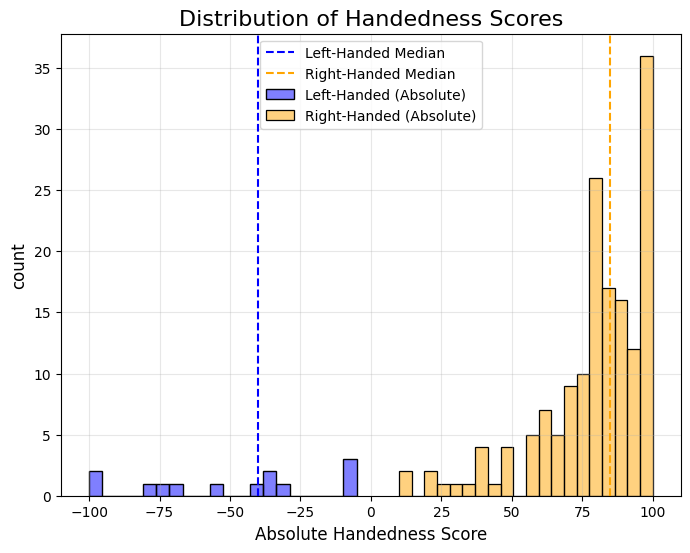

In [44]:
# Take absolute values of Handedness
left_handed_abs = left_handed['Handedness'].abs()
right_handed_abs = right_handed['Handedness'].abs()

plt.figure(figsize=(8, 6))
sns.histplot(left_handed['Handedness'], color='blue', label='Left-Handed (Absolute)', kde=False, bins=20, alpha=0.5)
sns.histplot(right_handed['Handedness'], color='orange', label='Right-Handed (Absolute)', kde=False, bins=20, alpha=0.5)


# mark medians
plt.axvline(left_handed['Handedness'].median(), color='blue', linestyle='--', label='Left-Handed Median')
plt.axvline(right_handed['Handedness'].median(), color='orange', linestyle='--', label='Right-Handed Median')

# Labels and title
plt.xlabel('Absolute Handedness Score', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.title('Distribution of Handedness Scores', fontsize=16)
plt.legend()

plt.grid(alpha=0.3)
plt.show()

In [45]:
mmp_correlation_matrix_list = []
for i in range(mmp_data.shape[0]):
    person = mmp_data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    #append to list
    mmp_correlation_matrix_list.append(person_matrix)
#append to column
mmp_data["correlation_matrix"] = mmp_correlation_matrix_list

In [46]:
mmp_data['correlation_matrix']

0      [[1.0, 0.46619928616491757, 0.5387587799680043...
1      [[1.0, 0.4145113094959292, 0.342818966658749, ...
2      [[0.9999999999999998, 0.2989986241314227, 0.52...
3      [[0.9999999999999998, 0.5081583697070787, 0.59...
4      [[1.0, 0.5963831451011642, 0.6588621195832001,...
                             ...                        
167    [[1.0, 0.5868952668034533, 0.6650024441927097,...
168    [[1.0, 0.2527353927273103, 0.6220543671787876,...
169    [[1.0, 0.4077766140820082, 0.5679625164532214,...
170    [[0.9999999999999998, 0.4373132861456234, 0.65...
171    [[1.0, 0.1745251119720137, 0.5239475526043362,...
Name: correlation_matrix, Length: 172, dtype: object

In [47]:
mmp_regions = list(hcp.mmp.labels.values())[1:]

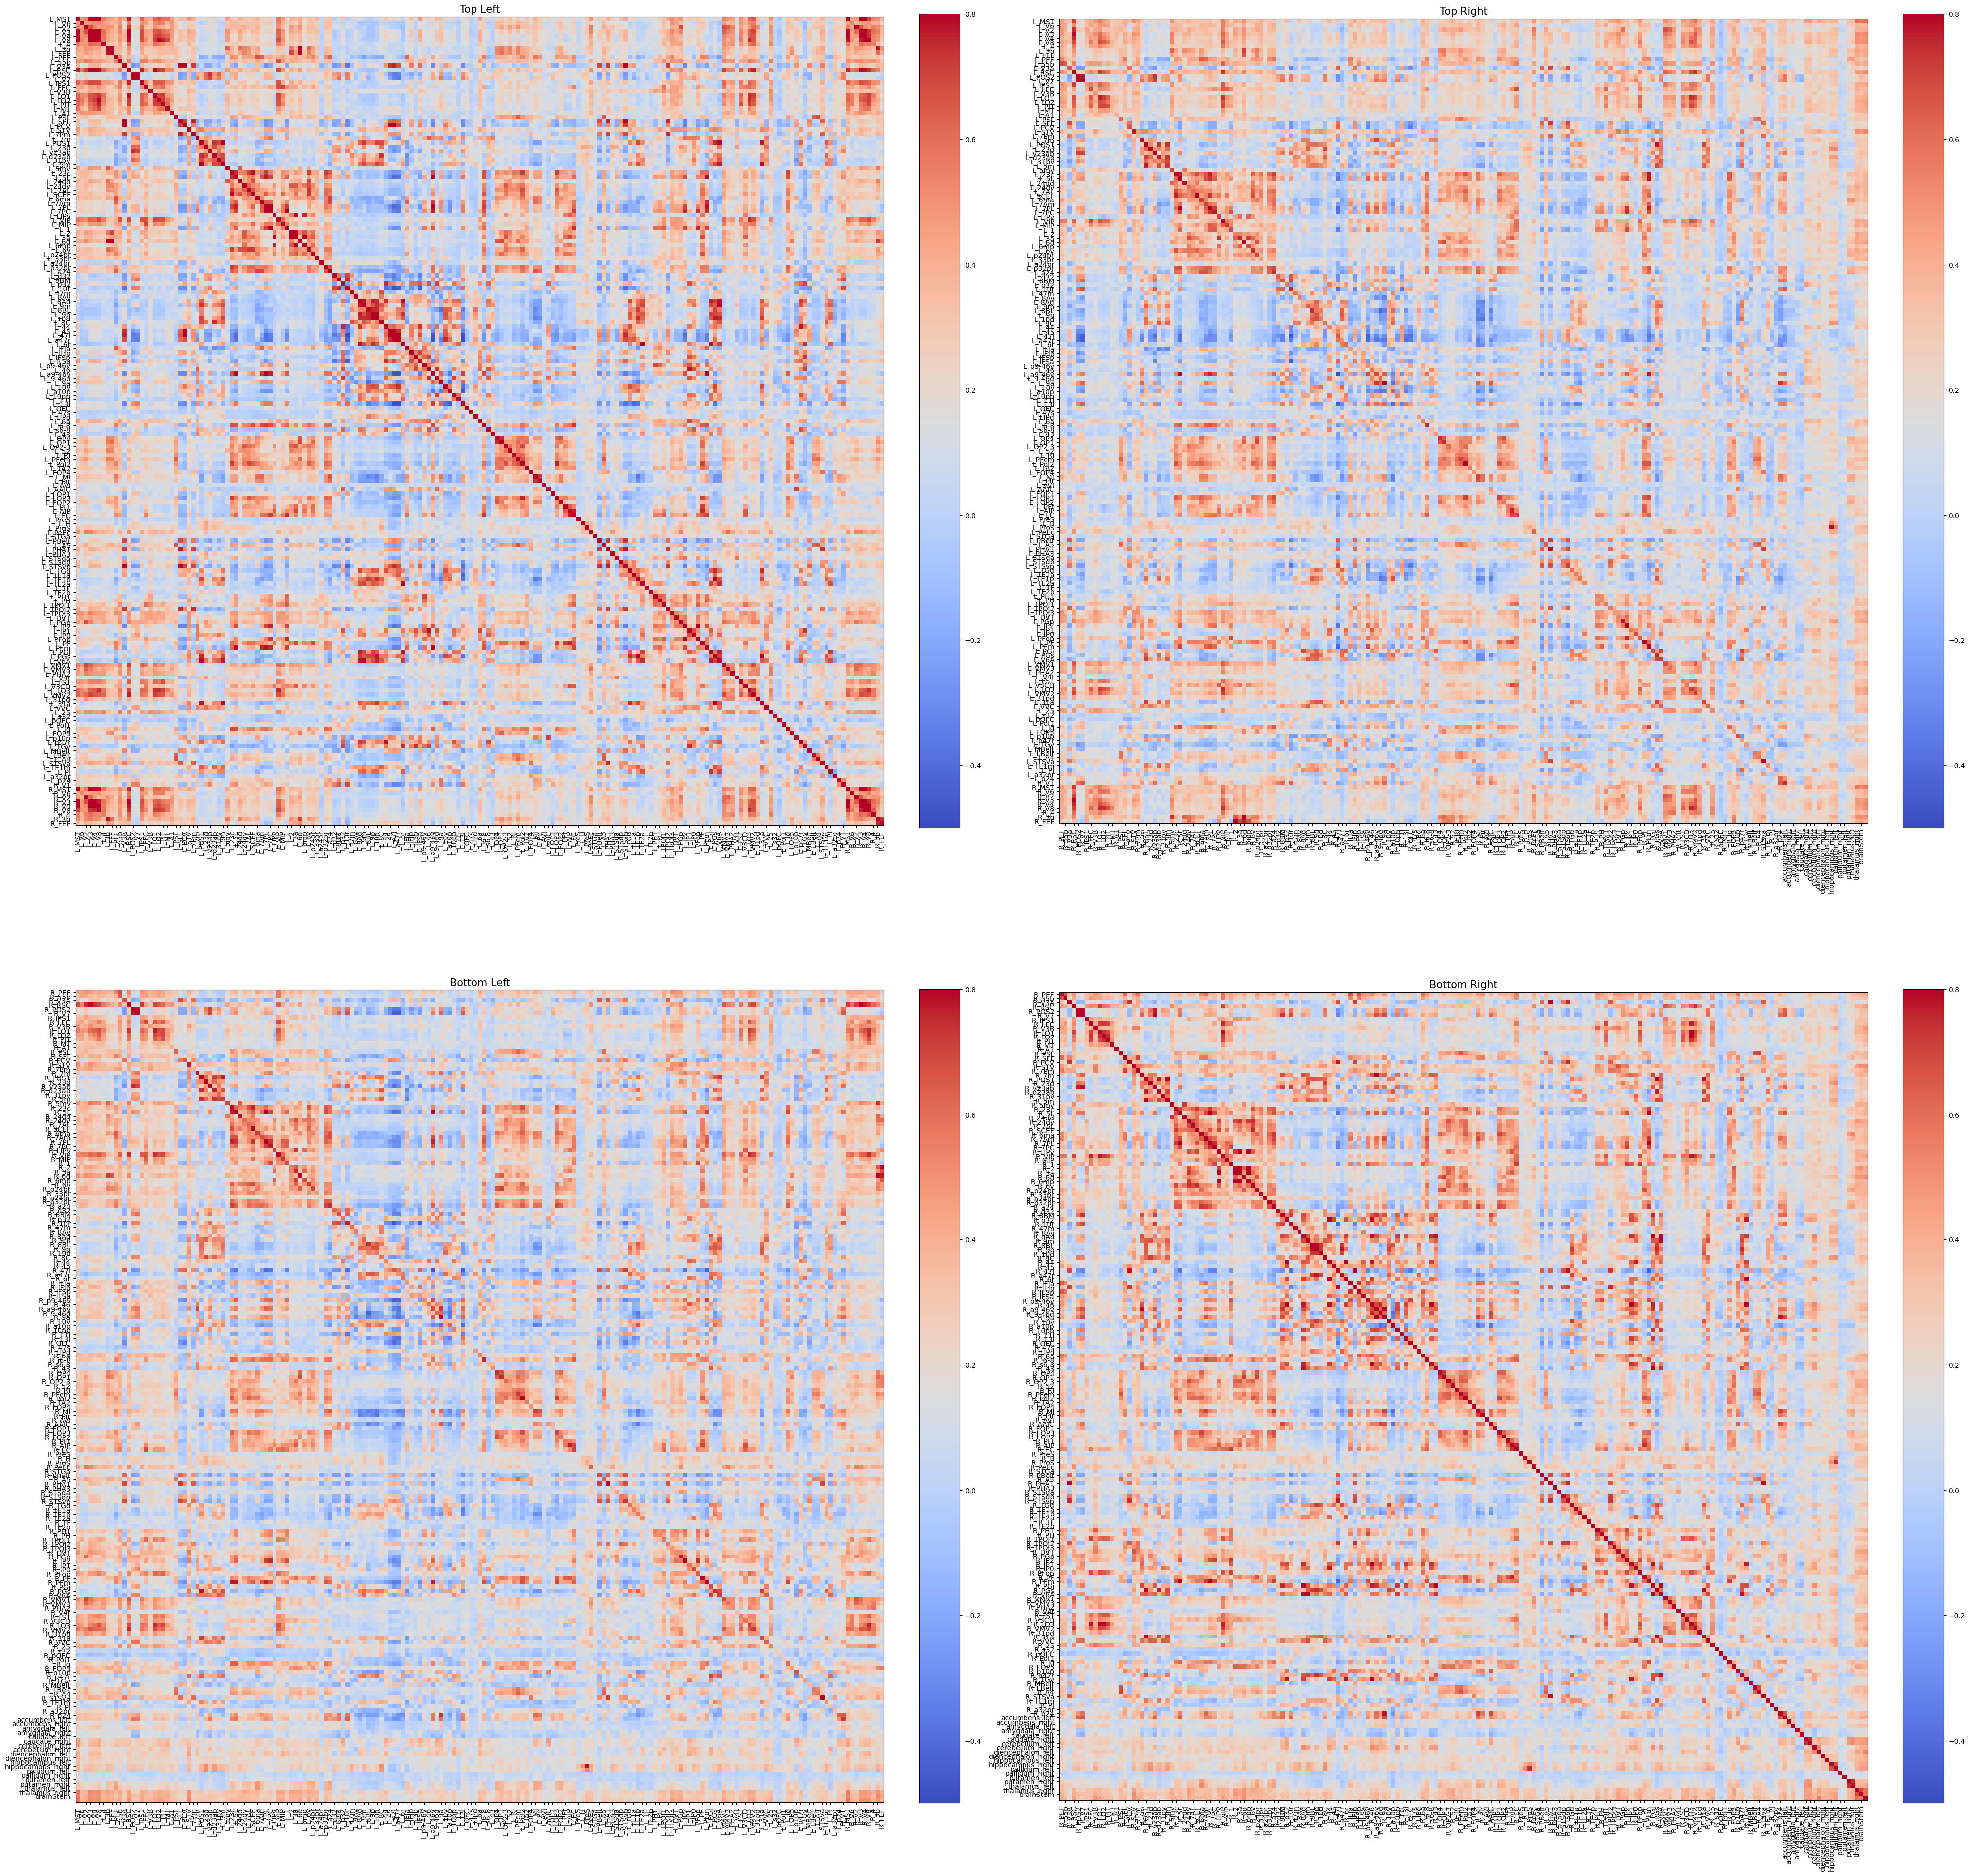

In [48]:
# Get the **first** correlation matrix to see for example
matrix = mmp_correlation_matrix_list[0]
labels = mmp_regions[1:] # mmp_regions[0] is just np.str_(''), leave it

# Define size of each quadrant
n = len(labels)  
half_n = n // 2  # Halfway point to split

fig, axes = plt.subplots(2, 2, figsize=(40, 40))

def plot_quadrant(ax, data, x_labels, y_labels, title):
    im = ax.imshow(data, cmap="coolwarm", vmin=-0.5, vmax=0.8)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels, fontsize=10, rotation=90)
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_title(title, fontsize=15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

# Top-left quadrant
plot_quadrant(axes[0, 0], matrix[:half_n, :half_n], labels[:half_n], labels[:half_n], "Top Left")

# Top-right quadrant
plot_quadrant(axes[0, 1], matrix[:half_n, half_n:], labels[half_n:], labels[:half_n], "Top Right")

# Bottom-left quadrant
plot_quadrant(axes[1, 0], matrix[half_n:, :half_n], labels[:half_n], labels[half_n:], "Bottom Left")

# Bottom-right quadrant
plot_quadrant(axes[1, 1], matrix[half_n:, half_n:], labels[half_n:], labels[half_n:], "Bottom Right")

plt.tight_layout()
plt.show()

In [49]:
# Dictionary to store sum of correlation values and count occurrences across subjects
pairwise_corr = {}

# Iterate over all correlation matrices (subjects)
for matrix in mmp_correlation_matrix_list:
    # Get the upper triangle of the matrix, excluding the diagonal
    triu_indices = np.triu_indices_from(matrix, k=1)
    values = matrix[triu_indices]

    # Get the region name pairs
    region_pairs = [(mmp_regions[i], mmp_regions[j]) for i, j in zip(*triu_indices)]

    # Create a DataFrame for sorting
    df = pd.DataFrame({
        "Region 1": [pair[0] for pair in region_pairs],
        "Region 2": [pair[1] for pair in region_pairs],
        "Correlation": values
    })

    # Sort by absolute correlation value (consider both positive and negative)
    df_sorted = df.sort_values(by="Correlation", ascending=False)
    
    # Select top 15 most positive and top 15 most negative correlations
    top_positive = df_sorted.head(15)
    top_negative = df_sorted.tail(15)  # Tail gets the most negative correlations

    # Combine both selections
    top_30 = pd.concat([top_positive, top_negative])

    # Aggregate correlation values for each region pair
    for _, row in top_30.iterrows():
        pair = (row["Region 1"], row["Region 2"])
        if pair not in pairwise_corr:
            pairwise_corr[pair] = {"sum": 0, "count": 0}
        pairwise_corr[pair]["sum"] += row["Correlation"]
        pairwise_corr[pair]["count"] += 1

# Compute average correlation values for each region pair
avg_corr_list = [
    {"Region 1": pair[0], "Region 2": pair[1], "Average Correlation": pairwise_corr[pair]["sum"] / pairwise_corr[pair]["count"]}
    for pair in pairwise_corr
]

# Convert to DataFrame and sort by absolute average correlation
df_avg_corr = pd.DataFrame(avg_corr_list).sort_values(by="Average Correlation", ascending=False)

# Select the final top 30 region pairs with highest absolute average correlation
final_top_30 = df_avg_corr.head(30)

# Display the results
print(final_top_30)

     Region 1 Region 2  Average Correlation
0        L_V1     R_V1             0.954988
1098     L_A4     R_A4             0.954090
1        L_V2     R_V2             0.942734
898     L_FFC    R_FFC             0.936894
865      L_V3     R_V1             0.927494
866      R_V1     R_V3             0.926878
540       L_1      R_2             0.924642
234      L_3b      R_1             0.922932
2        L_V2     L_V3             0.921081
415       L_4     R_3a             0.919865
578     L_SFL    R_SFL             0.919701
329     L_FEF    R_FEF             0.918987
113      L_3a      R_4             0.917899
199      R_9m     R_9p             0.916732
70        L_4     L_3a             0.916438
197      L_3b      L_1             0.916279
1016      L_4     L_3b             0.916278
11      L_V3A    R_V3A             0.915702
30       L_V3     R_V3             0.915024
69       L_3a     R_3a             0.913762
1067      L_1     R_3b             0.913597
36       L_V4     R_V4          

In [50]:
handedness_regions = [
    # 1. Primary Motor & Somatosensory Cortex
    "L_4", "R_4",  # Primary Motor Cortex (M1)
    "L_1", "L_2", "L_3a", "R_1", "R_2", "R_3a",  # Somatosensory Cortex (S1)
    "L_3b", "R_3b",  # Secondary Somatosensory Cortex

    # 2. Premotor & Supplementary Motor Areas (SMA, PMd, PMv)
    "L_6mp", "R_6mp",  # Supplementary Motor Area (SMA)
    "L_6ma", "R_6ma",  # Medial Premotor Cortex
    "L_6d", "R_6d",  # Dorsal Premotor Cortex (PMd) - Reach, grasp control
    "L_6r", "R_6r",  # Rostral Premotor Cortex - Higher-order motor control
    "L_6a", "R_6a",  # Anterior Premotor Cortex
    "L_FEF", "R_FEF",  # Frontal Eye Fields (FEF) - Eye-hand coordination
    "L_6v", "R_6v", # Ventral Premotor Cortex (PMv), crucial for movement execution"

    # 3. Parietal Cortex & Sensorimotor Integration
    "L_IPS1", "R_IPS1",  # Intraparietal Sulcus (IPS) - Sensorimotor integration
    "L_LIPv", "R_LIPv",
    "L_LIPd", "R_LIPd",
    "L_7AL", "R_7AL",  # Superior Parietal Lobule (SPL) - Hand coordination
    "L_7m", "R_7m",
    "L_7PC", "R_7PC",

    # 4. Corpus Callosum & Interhemispheric Connections
    "L_31pv", "R_31pv",
    "L_31pd", "R_31pd",
    "L_24dd", "R_24dd",  # Dorsal Anterior Cingulate Cortex - Motor learning
    "L_24dv", "R_24dv",  # Ventral Anterior Cingulate Cortex

    # 6. Prefrontal Cortex (Executive & Motor Control)
    "L_9-46d", "R_9-46d",  # Dorsolateral Prefrontal Cortex (DLPFC) - Movement decision-making
    "L_46", "R_46",
    "L_44", "R_44",  # Broca's area - Language-motor integration
    "L_45", "R_45",

    # 7. Additional Relevant Motor Control Regions
    "L_SCEF", "R_SCEF",  # Supplementary & Cingulate Eye Fields
    "L_MIP", "R_MIP",  # Medial Intraparietal - Reach planning
    "L_VIP", "R_VIP",  # Ventral Intraparietal - Visuomotor integration
    
    # 8. Subcortical Motor-related Areas
    "putamen_left", "putamen_right",
    "caudate_left", "caudate_right",
    "thalamus_left", "thalamus_right",
    "cerebellum_left", "cerebellum_right",

    # 9. Brainstem - Motor relay
    "brainStem"
]


In [51]:
def feature_row_get(target):
    target_index = mmp_regions.index(target)
    target_row = mmp_data['correlation_matrix'].apply(lambda x: x[target_index])
    
    return target_row


In [52]:
# Function to extract features automatically
def extract_features(region_list, data):
    """
    Extracts the correlation matrix rows for each brain region in region_list.
    
    Parameters:
    - region_list: List of brain region names (e.g., ["L_MT", "L_4", "R_4"])
    - data: DataFrame containing "correlation_matrix"
    
    Returns:
    - DataFrame with extracted features
    """
    # Copy the relevant columns first
    feature_data = data[["Handedness", "Handedness_Cat", "correlation_matrix"]].copy()
    # print(feature_data.shape)

    # Compute the mean of the entire correlation matrix as a baseline feature
    feature_data["matrix_mean"] = data["correlation_matrix"].apply(lambda x: np.mean(x))

    # Apply feature_row_get() dynamically and store in a dictionary
    for region in region_list:
        feature_data[region] = feature_row_get(region)

    return feature_data


In [53]:
# Extract features for handedness prediction
feature_data = extract_features(handedness_regions, mmp_data)
feature_data

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_4,R_4,L_1,L_2,L_3a,R_1,...,R_VIP,putamen_left,putamen_right,caudate_left,caudate_right,thalamus_left,thalamus_right,cerebellum_left,cerebellum_right,brainStem
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[0.44603460807054096, 0.4180526599268045, 0.49...","[0.5058448287380618, 0.4015377697499112, 0.512...","[0.40548299302723256, 0.3255226507827946, 0.46...","[0.3554718317313472, 0.25483166802262797, 0.36...","[0.39900973227227443, 0.41345739128627873, 0.5...","[0.4285198311027231, 0.2874295191200353, 0.430...",...,"[0.4205647964065872, 0.3996089074985924, 0.323...","[0.3100933161756262, 0.24881346059399678, 0.17...","[0.3265738264531844, 0.2825369441278569, 0.198...","[0.4531293279504429, 0.2600933635242887, 0.193...","[0.4690835728576636, 0.2937425413721241, 0.214...","[0.5864892059883535, 0.3648707037374211, 0.371...","[0.5582765289662259, 0.35101745169885495, 0.38...","[0.3219879883512635, 0.17588412845479667, 0.11...","[0.4157853760774209, 0.18428982548096604, 0.12...","[0.5856313541418544, 0.363891982671451, 0.3986..."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[-0.03625874806779633, 0.3554951523299754, 0.5...","[-0.10786685793218385, 0.30606096530910526, 0....","[0.1866388091202092, 0.5719445130192548, 0.707...","[0.2012457043420382, 0.535342102420762, 0.6948...","[0.23877921379849432, 0.463670940844406, 0.631...","[0.1580324252276484, 0.5356620622060693, 0.686...",...,"[0.1599645226285731, 0.5225234971414285, 0.565...","[0.2989966594350158, 0.02963297790273026, -0.1...","[0.28908567047301875, -0.08507595951425063, -0...","[0.3322084077834872, -0.07981750386082631, -0....","[0.3014892519165118, -0.11160216043970941, -0....","[0.5825102955540145, 0.007198172227728307, -0....","[0.5496595299756764, -0.020745895635067197, -0...","[0.4318418228626399, 0.10786656654299008, -0.0...","[0.30321061554931156, -0.061161524824678085, -...","[0.5698083573040247, 0.34655284202675646, 0.29..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.2557007884462401, 0.4163673796361299, 0.587...","[0.3319607392943346, 0.4335608090685443, 0.660...","[0.30591984028492586, 0.3901975349387497, 0.58...","[0.325970189999188, 0.40499778505999673, 0.534...","[0.31330878401442297, 0.3703670853318901, 0.59...","[0.26419372754132087, 0.39141084680597066, 0.5...",...,"[0.41718919884300165, 0.4468556407881708, 0.58...","[0.3608501034288935, 0.08720571776315682, 0.11...","[0.3666126674932228, 0.04576551554754129, 0.10...","[0.3780522503651181, 0.11468560440687055, 0.15...","[0.36721388756832324, 0.053474729456464885, 0....","[0.5161074827653371, 0.17155229937390812, 0.23...","[0.5746687762566225, 0.13914864892984888, 0.25...","[0.5436292719235283, 0.33733431936603103, 0.42...","[0.5351185488250705, 0.354959720876679, 0.4086...","[0.5656910983821719, 0.3687751577105434, 0.502..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.4339877528645952, 0.5040271371932618, 0.628...","[0.37742673354089434, 0.4739060736846943, 0.60...","[0.3937560464391664, 0.5432009909529222, 0.607...","[0.40808604943560123, 0.5336622651926306, 0.59...","[0.4405457977953715, 0.4653121108483167, 0.614...","[0.3717411816742993, 0.5696178109082224, 0.613...",...,"[0.4546844875980681, 0.6817560118565841, 0.598...","[0.2148320182060796, 0.008706104476269587, 0.0...","[0.22165574154445203, 0.032556552822297496, 0....","[0.37398040300674507, 0.085619029663636, 0.003...","[0.33336466695949396, 0.03706321085712994, -0....","[0.521820363701444, 0.39598278258570213, 0.369...","[0.4775837813669714, 0.361452635371305, 0.3442...","[0.6201374288752123, 0.50124541190932, 0.38606...","[0.6101966415107055, 0.42786985669847777, 0.34...","[0.506131300140526, 0.48203909591560734, 0.494..."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[0.45387901174031836, 0.5127461328419858, 0.57...","[0.4722164765751269, 0.5332245212475473, 0.

In [54]:
def flatten_features(row, region_list):
    """
    Flattens selected brain region features into a single numpy array.
    
    Parameters:
    - row: A single row from the DataFrame
    - region_list: List of selected brain regions
    
    Returns:
    - 1D numpy array containing all extracted feature values
    """
    # Flatten the correlation matrix (if applicable)
    corr_mat = np.array(row["correlation_matrix"]).flatten()

    # Extract all relevant region values dynamically
    region_values = [np.array(row[region]) for region in region_list if region in row]

    # Concatenate into one feature array
    return np.concatenate(region_values)


In [55]:
filtered_df = feature_data[(feature_data['Handedness'] > 25) | (feature_data['Handedness'] < -25)]
feature_data = filtered_df
feature_data.shape

(164, 71)

Could do random sampling of the right-handed group, but data size is too small

In [56]:
# Separate into left and right handed
left_handed = filtered_df[filtered_df['Handedness'] < 0]
right_handed = filtered_df[filtered_df['Handedness'] > 0]
print(left_handed.shape, right_handed.shape)

# Determine the number of samples to select from the right-handed data
num_samples = min(len(left_handed), len(right_handed))

# Randomly sample from the right-handed data
right_handed_sample = right_handed.sample(n=num_samples, random_state=42)

# Combine the left and right handed data
df_sampled = pd.concat([left_handed, right_handed_sample])
df_sampled.shape

# feature_data = df_sampled
# feature_data.shape

(10, 71) (154, 71)


(20, 71)

In [57]:
def SVM_w_sampling (sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    for i in range(5):
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)  # Convert to a 2D NumPy array
        y = feature_data["Handedness_Cat"]

        # Train-Test Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.4, stratify=None  # More variation by setting stratify=None
        )
        
        print(f"Run {i+1}: Before Oversampling - {Counter(y_train)}")

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print(f"After Oversampling - {Counter(y_train_resampled)}")

        # Train SVM Model
        model_class = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", probability=True, C=1.0, class_weight="balanced"))
        ])
        model_class.fit(X_train_resampled, y_train_resampled)
        y_pred = model_class.predict(X_test)

        # Balanced Accuracy & Confusion Matrix
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred) 
        conf_matrix = confusion_matrix(y_test, y_pred)

        print(f"Accuracy: {accuracy:.4f}, Balanced Accuracy: {balanced_acc:.4f}")
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval Calculation
        n_test = len(y_test)
        z_value = 1.96  # for ~95% CI
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)

        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        # Store results
        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final Results
    print(f"Final Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

In [58]:
SVM_w_sampling('SMOTE')

Run 1: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({1: 92, 0: 92})
Accuracy: 0.9394, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 62]]
95% CI for Accuracy: [0.8818, 0.9970]
Run 2: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9091, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 60]]
95% CI for Accuracy: [0.8397, 0.9784]
Run 3: Before Oversampling - Counter({1: 95, 0: 3})
After Oversampling - Counter({1: 95, 0: 95})
Accuracy: 0.8939, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 59]]
95% CI for Accuracy: [0.8197, 0.9682]
Run 4: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 5: Before Oversampling - Counter({1: 89, 0: 9})
After Oversampling - Counter({1: 89, 0: 89})
Accuracy: 0.9848, Balanced Accuracy

In [59]:
SVM_w_sampling('ADASYN')

Run 1: Before Oversampling - Counter({1: 90, 0: 8})
After Oversampling - Counter({1: 90, 0: 90})
Accuracy: 0.9697, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  2]
 [ 0 64]]
95% CI for Accuracy: [0.9283, 1.0111]
Run 2: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({0: 93, 1: 92})
Accuracy: 0.9394, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 62]]
95% CI for Accuracy: [0.8818, 0.9970]
Run 3: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({0: 95, 1: 94})
Accuracy: 0.9091, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 60]]
95% CI for Accuracy: [0.8397, 0.9784]
Run 4: Before Oversampling - Counter({1: 90, 0: 8})
After Oversampling - Counter({1: 90, 0: 90})
Accuracy: 0.9697, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  2]
 [ 0 64]]
95% CI for Accuracy: [0.9283, 1.0111]
Run 5: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({0: 95, 1: 93})
Accuracy: 0.9242, Balanced Accuracy

In [60]:
SVM_w_sampling('RandomUnderSampler')

Run 1: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({0: 4, 1: 4})
Accuracy: 0.5606, Balanced Accuracy: 0.6083
Confusion Matrix:
 [[ 4  2]
 [27 33]]
95% CI for Accuracy: [0.4409, 0.6803]
Run 2: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.5152, Balanced Accuracy: 0.7419
Confusion Matrix:
 [[ 4  0]
 [32 30]]
95% CI for Accuracy: [0.3946, 0.6357]
Run 3: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({0: 4, 1: 4})
Accuracy: 0.4091, Balanced Accuracy: 0.6750
Confusion Matrix:
 [[ 6  0]
 [39 21]]
95% CI for Accuracy: [0.2905, 0.5277]
Run 4: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.5909, Balanced Accuracy: 0.5484
Confusion Matrix:
 [[ 2  2]
 [25 37]]
95% CI for Accuracy: [0.4723, 0.7095]
Run 5: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.5606, Balanced Accuracy: 0.5323
C

In [61]:
SVM_w_sampling('RandomOverSampler')

Run 1: Before Oversampling - Counter({1: 88, 0: 10})
After Oversampling - Counter({1: 88, 0: 88})


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Accuracy: 1.0000, Balanced Accuracy: 1.0000
Confusion Matrix:
 [[66]]
95% CI for Accuracy: [1.0000, 1.0000]
Run 2: Before Oversampling - Counter({1: 90, 0: 8})
After Oversampling - Counter({1: 90, 0: 90})
Accuracy: 0.9697, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  2]
 [ 0 64]]
95% CI for Accuracy: [0.9283, 1.0111]
Run 3: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 4: Before Oversampling - Counter({1: 91, 0: 7})
After Oversampling - Counter({1: 91, 0: 91})
Accuracy: 0.9545, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  3]
 [ 0 63]]
95% CI for Accuracy: [0.9043, 1.0048]
Run 5: Before Oversampling - Counter({1: 97, 0: 1})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8636, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  9]
 [ 0 57]]
95% CI for Accuracy: [0.7808, 0.9464]
Final Average Accuracy: 

Only the training set is being resampled (either through SMOTE or undersampling), while the test set remains skewed. This means that even if the model learns to recognize left-handers better during training, it is still evaluated on a highly imbalanced test set, which can lead to misleading results.

In [62]:
def SVM_w_sampling_tuning(sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    # Define the SVM pipeline
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(probability=True))
    ])

    # Define hyperparameter grid for tuning
    param_grid = {
        "svc__C": [0.1, 1, 10],  
        "svc__gamma": ["scale", "auto"],  
        "svc__kernel": ["rbf", "linear"],
        "svc__class_weight": ["balanced"]
    }

    for i in range(3):
        print(f"\n===== Run {i+1} =====")
        
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)
        y = feature_data["Handedness_Cat"]

        # Train-test split (random_state=None for different splits each time)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.5, stratify=y, random_state=None
        )
        
        print("Before Sampling:", Counter(y_train)) 

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print("After Sampling:", Counter(y_train_resampled))  

        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="balanced_accuracy")
        grid_search.fit(X_train_resampled, y_train_resampled)

        # Best model after tuning
        best_model = grid_search.best_estimator_

        # Make predictions
        y_pred = best_model.predict(X_test)

        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        print("Best Hyperparameters:", grid_search.best_params_)
        print("Accuracy of SVM Model:", accuracy)
        print("Balanced Accuracy:", balanced_acc)
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval for Accuracy
        n_test = len(y_test)
        z_value = 1.96  
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)
        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final results
    print(f"\nFinal Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

In [63]:
SVM_w_sampling_tuning('SMOTE')


===== Run 1 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.926829268292683
Balanced Accuracy: 0.587012987012987
Confusion Matrix:
 [[ 1  4]
 [ 2 75]]
95% CI for Accuracy: [0.8705, 0.9832]

===== Run 2 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 3 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.926829268292683
Balanced Accura

In [64]:
SVM_w_sampling_tuning('ADASYN')


===== Run 1 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 2 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 76})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.9146341463414634
Balanced Accuracy: 0.487012987012987
Confusion Matrix:
 [[ 0  5]
 [ 2 75]]
95% CI for Accuracy: [0.8542, 0.9751]

===== Run 3 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 75})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accu

In [65]:
SVM_w_sampling_tuning('RandomOverSampler')


===== Run 1 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.926829268292683
Balanced Accuracy: 0.4935064935064935
Confusion Matrix:
 [[ 0  5]
 [ 1 76]]
95% CI for Accuracy: [0.8705, 0.9832]

===== Run 2 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.926829268292683
Balanced Accuracy: 0.4935064935064935
Confusion Matrix:
 [[ 0  5]
 [ 1 76]]
95% CI for Accuracy: [0.8705, 0.9832]

===== Run 3 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.92682926829

In [66]:
SVM_w_sampling_tuning('RandomUnderSampler')


===== Run 1 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.5365853658536586
Balanced Accuracy: 0.6597402597402597
Confusion Matrix:
 [[ 4  1]
 [37 40]]
95% CI for Accuracy: [0.4287, 0.6445]

===== Run 2 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.6463414634146342
Balanced Accuracy: 0.43766233766233764
Confusion Matrix:
 [[ 1  4]
 [25 52]]
95% CI for Accuracy: [0.5429, 0.7498]

===== Run 3 =====
Before Sampling: Counter({1: 77, 0: 5})
After Sampling: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.7317073170731707
Balanc

In [67]:
def SVM_w_sampling_tuning(sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    # Define the SVM pipeline
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(probability=True))
    ])

    # Define hyperparameter grid for tuning
    param_grid = {
        "svc__C": [0.1, 1, 10],  
        "svc__gamma": ["scale", "auto"],  
        "svc__kernel": ["rbf", "linear"],
        "svc__class_weight": ["balanced"]
    }

    for i in range(3):
        print(f"\n===== Run {i+1} =====")
        
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)
        y = feature_data["Handedness_Cat"]

        # Train-test split (random_state=None for different splits each time)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.5, stratify=y, random_state=None
        )
        
        print("Before Sampling:", Counter(y_train)) 

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print("After Sampling:", Counter(y_train_resampled))  

        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="balanced_accuracy")
        grid_search.fit(X_train_resampled, y_train_resampled)

        # Best model after tuning
        best_model = grid_search.best_estimator_

        # Make predictions
        y_pred = best_model.predict(X_test)

        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        print("Best Hyperparameters:", grid_search.best_params_)
        print("Accuracy of SVM Model:", accuracy)
        print("Balanced Accuracy:", balanced_acc)
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval for Accuracy
        n_test = len(y_test)
        z_value = 1.96  
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)
        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final results
    print(f"\nFinal Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

Initially, SVM was overfitting (SMOTE, ADASYN, or RandomOverSampling), all right-handed predictions and 0 left-handed predictions, leading to high accuracy (~94%) but a balanced accuracy of ~0.5.

I tried undersampling the majority class, which reduced overfitting (accuracy ~65%, balanced accuracy ~0.55). The challenge now is that the dataset has very few left-handers, and SMOTE can’t create reliable synthetic samples from such limited data. I'm considering manually balancing the test set or re-evaluating whether rs-fMRI features contain enough lateralization signals to predict handedness reliably. 



### CNN

In [69]:
def CNN_w_sampling(sampling_method, test_size=0.3, batch_size=16, epochs=20, num_runs=5):
    """
    Builds and trains a CNN for handedness prediction using:
    - Features from flatten_features()
    - Flattened correlation_matrix values

    Parameters:
    - sampling_method: Type of resampling ('SMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler').
    - test_size: Proportion of dataset allocated for testing.
    - batch_size: Training batch size.
    - epochs: Number of training epochs.
    - num_runs: Number of independent runs for variability in results.

    Returns:
    - DataFrame with summarized results across runs.
    """

    test_results = []

    for i in range(1, num_runs + 1):
        print(f"\n===== RUN {i} =====")

        # -------------------------------
        # 1. Feature Extraction (Unified X)
        # -------------------------------
        # Extract features using flatten_features()
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X_features = np.vstack(X_list.values)  # shape: (n_samples, num_features)

        # Flatten correlation matrices and add as additional features
        X_corr_flattened = np.array(feature_data["correlation_matrix"].tolist()).reshape(X_features.shape[0], -1)  

        # Combine both into a single X
        X = np.hstack([X_features, X_corr_flattened])  # Final X shape: (n_samples, num_features + flattened_corr)

        # Target variable
        y = feature_data["Handedness_Cat"]

        # -------------------------------
        # 2. Train-Test Split
        # -------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=None
        )

        print(f"Run {i}: Before Sampling - {Counter(y_train)}")

        # -------------------------------
        # 3. Standardize Features
        # -------------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # -------------------------------
        # 4. Apply Oversampling to Training Set
        # -------------------------------
        min_class_count = min(Counter(y_train).values())  # Determine smallest class count
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "RandomUnderSampler":
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == "RandomOverSampler":
            sampler = RandomOverSampler(random_state=None)
        else:
            raise ValueError("Invalid sampling method. Choose from 'SMOTE', 'ADASYN', 'RandomOverSampler', or 'RandomUnderSampler'.")

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)

        print(f"After Sampling - {Counter(y_train_resampled)}")

        # -------------------------------
        # 5. Build CNN Model
        # -------------------------------
        input_features = Input(shape=(X_train_resampled.shape[1],), name="feature_input")
        x = Dense(128, activation="relu")(input_features)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Dense(64, activation="relu")(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        output = Dense(1, activation="sigmoid")(x)

        model = Model(inputs=input_features, outputs=output)
        model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

        # -------------------------------
        # 6. Train Model
        # -------------------------------
        model.fit(
            X_train_resampled, y_train_resampled,
            validation_data=(X_test_scaled, y_test),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  # Hide training output
        )

        # -------------------------------
        # 7. Evaluate Model
        # -------------------------------
        y_pred_probs = model.predict(X_test_scaled)
        y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary labels

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        print('y_test:', Counter(y_test))
        print("\nClassification Report:\n", classification_report(y_test, y_pred))
        print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print(f"\nRun {i} Metrics:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")

        # Store results
        test_results.append({
            "Run": i,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Balanced Accuracy": balanced_acc
        })

    # Final Results
    df_results = pd.DataFrame(test_results)
    print("\n===== FINAL SUMMARY ACROSS RUNS =====")
    print(df_results)
    print("\nMean Performance:")
    print(df_results.mean())

    return model, df_results


In [70]:
CNN_w_sampling('RandomUnderSampler', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 7, 1: 7})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.09      1.00      0.16         3
           1       1.00      0.34      0.51        47

    accuracy                           0.38        50
   macro avg       0.54      0.67      0.34        50
weighted avg       0.95      0.38      0.49        50


Confusion Matrix:
 [[ 3  0]
 [31 16]]

Run 1 Metrics:
Accuracy: 0.3800
Precision: 1.0000
Recall: 0.3404
F1 Score: 0.5079
Balanced Accuracy: 0.6702

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 7, 1: 7})
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/stepWARNING:tensorflow:6 out of the last 7 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x15b8fe5c0> triggered tf.function retrac

(<Functional name=functional_6, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.38   1.000000  0.340426  0.507937           0.670213
 1    2      0.24   1.000000  0.191489  0.321429           0.595745
 2    3      0.54   0.928571  0.553191  0.693333           0.443262
 3    4      0.40   1.000000  0.361702  0.531250           0.680851
 4    5      0.48   0.956522  0.468085  0.628571           0.567376)

In [71]:
CNN_w_sampling('SMOTE', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.96      0.98      0.97        47

    accuracy                           0.94        50
   macro avg       0.73      0.66      0.68        50
weighted avg       0.93      0.94      0.93        50


Confusion Matrix:
 [[ 1  2]
 [ 1 46]]

Run 1 Metrics:
Accuracy: 0.9400
Precision: 0.9583
Recall: 0.9787
F1 Score: 0.9684
Balanced Accuracy: 0.6560

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
      

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 3: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 3 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 4 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 4: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 4 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 5 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 5: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.98      0.96        47

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50


Confusion Matrix:
 [[ 0  3]
 [ 1 46]]

Run 5 Metrics:
Accuracy: 0.9200
Precision: 0.9388
Recall: 0.9787
F1 Score: 0.9583
Balanced Accuracy: 0.4894

===== FINAL SUMMARY ACROSS RUNS =====
   Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
0    1      0.94   0.958333  0.978723  0.968421           0.656028
1    2      0.94   0.940000  1.000000  0.969072           0.500000
2    3      0.94   0.940000  1.000000  0.969072           0.500000
3    4      0.94   0.940000  1.0

(<Functional name=functional_11, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.94   0.958333  0.978723  0.968421           0.656028
 1    2      0.94   0.940000  1.000000  0.969072           0.500000
 2    3      0.94   0.940000  1.000000  0.969072           0.500000
 3    4      0.94   0.940000  1.000000  0.969072           0.500000
 4    5      0.92   0.938776  0.978723  0.958333           0.489362)

In [72]:
CNN_w_sampling('ADASYN', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 105})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.96      0.96      0.96        47

    accuracy                           0.92        50
   macro avg       0.65      0.65      0.65        50
weighted avg       0.92      0.92      0.92        50


Confusion Matrix:
 [[ 1  2]
 [ 2 45]]

Run 1 Metrics:
Accuracy: 0.9200
Precision: 0.9574
Recall: 0.9574
F1 Score: 0.9574
Balanced Accuracy: 0.6454

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 109, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
      

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 5: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 109, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.98      0.96        47

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50


Confusion Matrix:
 [[ 0  3]
 [ 1 46]]

Run 5 Metrics:
Accuracy: 0.9200
Precision: 0.9388
Recall: 0.9787
F1 Score: 0.9583
Balanced Accuracy: 0.4894

===== FINAL SUMMARY ACROSS RUNS =====
   Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
0    1      0.92   0.957447  0.957447  0.957447           0.645390
1    2      0.96   0.959184  1.000000  0.979167           0.666667
2    3      0.92   0.938776  0.978723  0.958333           0.489362
3    4      0.94   0.940000  1.0

(<Functional name=functional_16, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.92   0.957447  0.957447  0.957447           0.645390
 1    2      0.96   0.959184  1.000000  0.979167           0.666667
 2    3      0.92   0.938776  0.978723  0.958333           0.489362
 3    4      0.94   0.940000  1.000000  0.969072           0.500000
 4    5      0.92   0.938776  0.978723  0.958333           0.489362)

In [73]:
CNN_w_sampling('RandomOverSampler', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.98      0.96        47

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50


Confusion Matrix:
 [[ 0  3]
 [ 1 46]]

Run 1 Metrics:
Accuracy: 0.9200
Precision: 0.9388
Recall: 0.9787
F1 Score: 0.9583
Balanced Accuracy: 0.4894

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
      

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 3: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 3 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 4 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 4: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 107, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.96      0.96      0.96        47

    accuracy                           0.92        50
   macro avg       0.65      0.65      0.65        50
weighted avg       0.92      0.92      0.92        50


Confusion Matrix:
 [[ 1  2]
 [ 2 45]]

Run 4 Metrics:
Accuracy: 0.9200
Precision: 0.9574
Recall: 0.9574
F1 Score: 0.9574
Balanced Accuracy: 0.6454

===== RUN 5 =====
Run 5: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94 

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
0    1      0.92   0.938776  0.978723  0.958333           0.489362
1    2      0.94   0.940000  1.000000  0.969072           0.500000
2    3      0.94   0.940000  1.000000  0.969072           0.500000
3    4      0.92   0.957447  0.957447  0.957447           0.645390
4    5      0.94   0.940000  1.000000  0.969072           0.500000

Mean Performance:
Run                  3.000000
Accuracy             0.932000
Precision            0.943244
Recall               0.987234
F1 Score             0.964599
Balanced Accuracy    0.526950
dtype: float64


(<Functional name=functional_21, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.92   0.938776  0.978723  0.958333           0.489362
 1    2      0.94   0.940000  1.000000  0.969072           0.500000
 2    3      0.94   0.940000  1.000000  0.969072           0.500000
 3    4      0.92   0.957447  0.957447  0.957447           0.645390
 4    5      0.94   0.940000  1.000000  0.969072           0.500000)

If after all of this, balanced accuracy is ~0.5, it’s possible that rfMRI correlations aren’t sufficient to predict handedness.

Instead of the `handedness_regions`, use the significant regions that Daniel found by Zhuoxuan.

In [74]:
significant_regions = ['L_SFL', 'L_1', 'L_44', 'L_OFC', 'L_TA2', 'L_PHA1', 'L_TE1a', 'L_DVT', 'L_pOFC', 'R_PEF', 'R_VIP', 'R_1', 'R_11l', 'R_OP4', 'R_OP2-3', 'R_PFcm', 'R_H', 'R_31pd']

In [75]:
# Extract features for handedness prediction using significant regions only
feature_data = extract_features(significant_regions, mmp_data)
feature_data

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_SFL,L_1,L_44,L_OFC,L_TA2,L_PHA1,...,L_pOFC,R_PEF,R_VIP,R_1,R_11l,R_OP4,R_OP2-3,R_PFcm,R_H,R_31pd
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[0.3231818293285933, 0.05654510021135424, 0.10...","[0.40548299302723256, 0.3255226507827946, 0.46...","[0.18769119250623695, -0.03247958017999629, 0....","[-0.00896086940499581, -0.0009267744574111396,...","[0.19717832154389545, 0.18318945343147044, 0.2...","[0.2730769869303734, 0.13747693271662473, 0.32...",...,"[0.14748978258422882, 0.08180267581047104, 0.1...","[0.3329013935755421, 0.41701490613493913, 0.41...","[0.4205647964065872, 0.3996089074985924, 0.323...","[0.4285198311027231, 0.2874295191200353, 0.430...","[0.1514348770978374, 0.16488687470795674, 0.11...","[0.26240956085829736, 0.30196211026039016, 0.4...","[0.39555475648252036, 0.30317881062080554, 0.4...","[0.17288038170138673, 0.3374536196379342, 0.36...","[0.23871016190416916, 0.15422921859463767, 0.2...","[0.25153981626071253, 0.010101548149905461, 0...."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[0.06698753717245602, -0.001580193770690181, 0...","[0.1866388091202092, 0.5719445130192548, 0.707...","[0.13676359745648892, -0.02797425907077241, -0...","[0.11493805025934718, -0.0013849737419006226, ...","[0.043110057415732775, 0.3447825649399157, 0.4...","[0.17406376876018168, 0.17651927275145093, 0.3...",...,"[0.1472324962964217, -0.024880862479216823, -0...","[0.07238388864994358, 0.4032154858329246, 0.46...","[0.1599645226285731, 0.5225234971414285, 0.565...","[0.1580324252276484, 0.5356620622060693, 0.686...","[0.14278950745532318, -0.009159514255934956, -...","[0.17400213798792433, 0.4307686398020671, 0.54...","[0.40046465943884524, 0.35181316194880685, 0.4...","[0.14236476794781466, 0.4921388315840523, 0.56...","[0.2648126642646149, 0.18479058542143983, 0.19...","[0.14526858366687959, -0.09532112804837921, -0..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.0918866283273426, 0.19386798179533493, 0.20...","[0.30591984028492586, 0.3901975349387497, 0.58...","[0.2536316598394608, 0.19404334824825625, 0.37...","[-0.02801172671975958, -0.04697965457753488, -...","[0.2198098596093181, 0.23114000824523867, 0.27...","[0.36646897028720277, 0.39874347884005007, 0.5...",...,"[-0.019619433739468443, -0.0046764236749861346...","[0.34036289008197357, 0.289746822627155, 0.437...","[0.41718919884300165, 0.4468556407881708, 0.58...","[0.26419372754132087, 0.39141084680597066, 0.5...","[0.34569407436177335, 0.1494121493081389, 0.25...","[0.41373521794675144, 0.33028894511079593, 0.6...","[0.44533340219237627, 0.27793781425111846, 0.5...","[0.4060008930264692, 0.33263416123880224, 0.50...","[0.2608292245850585, 0.3772893078121869, 0.400...","[0.3624888532832297, 0.2656802231290284, 0.272..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.29087313908719487, 0.2224430676971492, 0.20...","[0.3937560464391664, 0.5432009909529222, 0.607...","[0.22126890579465794, 0.21479480215111704, 0.1...","[0.10089722157103038, 0.020052195241493882, -0...","[0.08259814464532861, 0.3866003735432504, 0.44...","[0.15509847854819422, 0.10540327848196956, 0.1...",...,"[-0.07915703705313956, -0.04486858125668527, -...","[0.27986084978719594, 0.5374640024219773, 0.48...","[0.4546844875980681, 0.6817560118565841, 0.598...","[0.3717411816742993, 0.5696178109082224, 0.613...","[0.22275080214774204, 0.08456732127690333, 0.1...","[0.3021224600625375, 0.4480134547876782, 0.612...","[0.4045878721336501, 0.45058199032370183, 0.56...","[0.31621284091898877, 0.5339321991098424, 0.56...","[0.15404737668443316, 0.22019327330562305, 0.1...","[0.1637346467651524, -0.04210453002674888, -0...."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[0.24140340892238749, 0.1873466908727359, 0.17...","[0.45131751729769015, 0.6203443289412882, 0.62...","[0.270217899258357, 0.19558515200519314, 0.249...","[

In [76]:
SVM_w_sampling('SMOTE')

Run 1: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9275, Balanced Accuracy: 0.4923
Confusion Matrix:
 [[ 0  4]
 [ 1 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 2: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 3: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 4: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9420, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 65]]
95% CI for Accuracy: [0.8869, 0.9972]
Run 5: Before Oversampling - Counter({1: 93, 0: 10})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9420, Balanced Accurac

In [77]:
SVM_w_sampling_tuning('SMOTE')


===== Run 1 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.49375
Confusion Matrix:
 [[ 0  6]
 [ 1 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 2 =====
Before Sampling: Counter({1: 80, 0: 6})
After Sampling: Counter({1: 80, 0: 80})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  7]
 [ 0 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 3 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion 

In [78]:
SVM_w_sampling('ADASYN')

Run 1: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 95})
Accuracy: 0.9275, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 2: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 93})
Accuracy: 0.9275, Balanced Accuracy: 0.4923
Confusion Matrix:
 [[ 0  4]
 [ 1 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 3: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 94})
Accuracy: 0.9275, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 4: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 92})
Accuracy: 0.9275, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 5: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 92})
Accuracy: 0.9275, Balanced Accuracy

In [79]:
SVM_w_sampling_tuning('ADASYN')


===== Run 1 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({0: 80, 1: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.49375
Confusion Matrix:
 [[ 0  6]
 [ 1 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 2 =====
Before Sampling: Counter({1: 80, 0: 6})
After Sampling: Counter({0: 81, 1: 80})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.872093023255814
Balanced Accuracy: 0.47468354430379744
Confusion Matrix:
 [[ 0  7]
 [ 4 75]]
95% CI for Accuracy: [0.8015, 0.9427]

===== Run 3 =====
Before Sampling: Counter({1: 80, 0: 6})
After Sampling: Counter({1: 80, 0: 80})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accu

In [80]:
SVM_w_sampling('RandomOverSampler')

Run 1: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 2: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 3: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 4: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({1: 96, 0: 96})
Accuracy: 0.9130, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 63]]
95% CI for Accuracy: [0.8466, 0.9795]
Run 5: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({1: 96, 0: 96})
Accuracy: 0.9130, Balanced Accuracy

In [81]:
SVM_w_sampling_tuning('RandomOverSampler')


===== Run 1 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0 80]]
95% CI for Accuracy: [0.8764, 0.9841]

===== Run 2 =====
Before Sampling: Counter({1: 80, 0: 6})
After Sampling: Counter({1: 80, 0: 80})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  7]
 [ 0 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 3 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matr

In [82]:
SVM_w_sampling('RandomUnderSampler')

Run 1: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({0: 7, 1: 7})
Accuracy: 0.6522, Balanced Accuracy: 0.5079
Confusion Matrix:
 [[ 2  4]
 [20 43]]
95% CI for Accuracy: [0.5398, 0.7646]
Run 2: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({0: 9, 1: 9})
Accuracy: 0.4493, Balanced Accuracy: 0.4731
Confusion Matrix:
 [[ 2  2]
 [36 29]]
95% CI for Accuracy: [0.3319, 0.5666]
Run 3: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({0: 8, 1: 8})
Accuracy: 0.4203, Balanced Accuracy: 0.5031
Confusion Matrix:
 [[ 3  2]
 [38 26]]
95% CI for Accuracy: [0.3038, 0.5368]
Run 4: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.7101, Balanced Accuracy: 0.5219
Confusion Matrix:
 [[ 2  5]
 [15 47]]
95% CI for Accuracy: [0.6031, 0.8172]
Run 5: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.5362, Balanced Accuracy: 0.5518
C

In [83]:
SVM_w_sampling_tuning('RandomUnderSampler')


===== Run 1 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({0: 7, 1: 7})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.5348837209302325
Balanced Accuracy: 0.51875
Confusion Matrix:
 [[ 3  3]
 [37 43]]
95% CI for Accuracy: [0.4295, 0.6403]

===== Run 2 =====
Before Sampling: Counter({1: 79, 0: 7})
After Sampling: Counter({0: 7, 1: 7})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.5813953488372093
Balanced Accuracy: 0.6208333333333333
Confusion Matrix:
 [[ 4  2]
 [34 46]]
95% CI for Accuracy: [0.4771, 0.6857]

===== Run 3 =====
Before Sampling: Counter({1: 80, 0: 6})
After Sampling: Counter({0: 6, 1: 6})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.6511627906976745
Balanced Accuracy

In [84]:
CNN_w_sampling('SMOTE')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.96      0.94        48

    accuracy                           0.88        52
   macro avg       0.46      0.48      0.47        52
weighted avg       0.85      0.88      0.87        52


Confusion Matrix:
 [[ 0  4]
 [ 2 46]]

Run 1 Metrics:
Accuracy: 0.8846
Precision: 0.9200
Recall: 0.9583
F1 Score: 0.9388
Balanced Accuracy: 0.4792

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
      

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 5: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.94      1.00      0.97        48

    accuracy                           0.94        52
   macro avg       0.97      0.62      0.68        52
weighted avg       0.95      0.94      0.93        52


Confusion Matrix:
 [[ 1  3]
 [ 0 48]]

Run 5 Metrics:
Accuracy: 0.9423
Precision: 0.9412
Recall: 1.0000
F1 Score: 0.9697
Balanced Accuracy: 0.6250

===== FINAL SUMMARY ACROSS RUNS =====
   Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
0    1  0.884615   0.920000  0.958333  0.938776           0.479167
1    2  0.884615   0.920000  0.958333  0.938776           0.479167
2    3  0.884615   0.920000  0.958333  0.938776           0.479167
3    4  0.923077   0.923077  1.0

(<Functional name=functional_26, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.884615   0.920000  0.958333  0.938776           0.479167
 1    2  0.884615   0.920000  0.958333  0.938776           0.479167
 2    3  0.884615   0.920000  0.958333  0.938776           0.479167
 3    4  0.923077   0.923077  1.000000  0.960000           0.500000
 4    5  0.942308   0.941176  1.000000  0.969697           0.625000)

In [87]:
CNN_w_sampling('ADASYN')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy                           0.92        52
   macro avg       0.46      0.50      0.48        52
weighted avg       0.85      0.92      0.89        52


Confusion Matrix:
 [[ 0  4]
 [ 0 48]]

Run 1 Metrics:
Accuracy: 0.9231
Precision: 0.9231
Recall: 1.0000
F1 Score: 0.9600
Balanced Accuracy: 0.5000

===== RUN 2 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy                           0.92        52
   macro avg       0.46      0.50      0.48        52
weighted avg       0.85      0.92      0.89        52


Confusion Matrix:
 [[ 0  4]
 [ 0 48]]

Run 2 Metrics:
Accuracy: 0.9231
Precision: 0.9231
Recall: 1.0000
F1 Score: 0.9600
Balanced Accuracy: 0.5000

===== RUN 3 =====
Run 3: Before Sampling - Counter({1: 111, 0: 9})

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy                           0.92        52
   macro avg       0.46      0.50      0.48        52
weighted avg       0.85      0.92      0.89        52


Confusion Matrix:
 [[ 0  4]
 [ 0 48]]

Run 3 Metrics:
Accuracy: 0.9231
Precision: 0.9231
Recall: 1.0000
F1 Score: 0.9600
Balanced Accuracy: 0.5000

===== RUN 4 =====
Run 4: Before Sampling - Counter({1: 111, 0: 9})


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.96      0.94        48

    accuracy                           0.88        52
   macro avg       0.46      0.48      0.47        52
weighted avg       0.85      0.88      0.87        52


Confusion Matrix:
 [[ 0  4]
 [ 2 46]]

Run 4 Metrics:
Accuracy: 0.8846
Precision: 0.9200
Recall: 0.9583
F1 Score: 0.9388
Balanced Accuracy: 0.4792

===== RUN 5 =====
Run 5: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 109})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy       

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(<Functional name=functional_38, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.923077   0.923077  1.000000  0.960000           0.500000
 1    2  0.923077   0.923077  1.000000  0.960000           0.500000
 2    3  0.923077   0.923077  1.000000  0.960000           0.500000
 3    4  0.884615   0.920000  0.958333  0.938776           0.479167
 4    5  0.923077   0.923077  1.000000  0.960000           0.500000)

In [88]:
CNN_w_sampling('RandomOverSampler')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy                           0.92        52
   macro avg       0.46      0.50      0.48        52
weighted avg       0.85      0.92      0.89        52


Confusion Matrix:
 [[ 0  4]
 [ 0 48]]

Run 1 Metrics:
Accuracy: 0.9231
Precision: 0.9231
Recall: 1.0000
F1 Score: 0.9600
Balanced Accuracy: 0.5000

===== RUN 2 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      1.00      0.96        48

    accuracy                           0.92        52
   macro avg       0.46      0.50      0.48        52
weighted avg       0.85      0.92      0.89        52


Confusion Matrix:
 [[ 0  4]
 [ 0 48]]

Run 2 Metrics:
Accuracy: 0.9231
Precision: 0.9231
Recall: 1.0000
F1 Score: 0.9600
Balanced Accuracy: 0.5000

===== RUN 3 =====
Run 3: Before Sampling - Counter({1: 111, 0: 9})


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.98      0.95        48

    accuracy                           0.90        52
   macro avg       0.46      0.49      0.47        52
weighted avg       0.85      0.90      0.88        52


Confusion Matrix:
 [[ 0  4]
 [ 1 47]]

Run 3 Metrics:
Accuracy: 0.9038
Precision: 0.9216
Recall: 0.9792
F1 Score: 0.9495
Balanced Accuracy: 0.4896

===== RUN 4 =====
Run 4: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.98      0.95        48

    accuracy       

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(<Functional name=functional_43, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.923077   0.923077  1.000000  0.960000           0.500000
 1    2  0.923077   0.923077  1.000000  0.960000           0.500000
 2    3  0.903846   0.921569  0.979167  0.949495           0.489583
 3    4  0.903846   0.921569  0.979167  0.949495           0.489583
 4    5  0.923077   0.923077  1.000000  0.960000           0.500000)

In [89]:
CNN_w_sampling('RandomUnderSampler')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({0: 9, 1: 9})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.25      0.09         4
           1       0.91      0.65      0.76        48

    accuracy                           0.62        52
   macro avg       0.48      0.45      0.42        52
weighted avg       0.85      0.62      0.70        52


Confusion Matrix:
 [[ 1  3]
 [17 31]]

Run 1 Metrics:
Accuracy: 0.6154
Precision: 0.9118
Recall: 0.6458
F1 Score: 0.7561
Balanced Accuracy: 0.4479

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({0: 9, 1: 9})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.25      0.07         4
           1  

(<Functional name=functional_48, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.615385   0.911765  0.645833  0.756098           0.447917
 1    2  0.480769   0.888889  0.500000  0.640000           0.375000
 2    3  0.538462   0.961538  0.520833  0.675676           0.635417
 3    4  0.538462   0.875000  0.583333  0.700000           0.291667
 4    5  0.500000   0.923077  0.500000  0.648649           0.500000)